# **SUPERVISED MACHINE LEARNING**
**VEHICLE CLASSIFICATION** `(2-STAGE HIERARCHICAL PIPELINE)`


## APPROACH:
*   Stage 1 — Binary classifier: car vs non_car  (bus+van combined → balanced)
*   Stage 2 — Binary classifier: bus vs van       (on non_car subset)


*   KEY METRIC : Macro F1-score (handles imbalance correctly)
*   FIGURES    : 16 publication-quality plots saved to working directory








# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, learning_curve)
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.decomposition   import PCA
from sklearn.metrics         import (classification_report, confusion_matrix,precision_score,
                                     f1_score, roc_auc_score, roc_curve, auc,accuracy_score,
                                     ConfusionMatrixDisplay,recall_score)

# Global features for Visualizations

In [2]:
P_ORIG = {'car': '#2166AC', 'bus': '#D85A30', 'van': '#1D9E75'}
P_S1   = {'car': '#2166AC', 'non_car': '#E07B39'}
P_S2   = {'bus': '#D85A30', 'van':     '#1D9E75'}
BAR_C  = ['#4393C3', '#92C5DE', '#2166AC', '#D6604D', '#B2182B', '#74ADD1']
BAR_C2 = ['#66C2A5', '#A6D96A', '#1D9E75', '#9970AB', '#762A83', '#5AAE61']
SHORT  = ['LR', 'DT', 'RF', 'GB', 'SVM', 'KNN']
SPLIT_COLORS = {'Train': '#2166AC', 'Validation': '#F4A261', 'Test': '#E63946'}

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# Import Data

In [3]:
df       = pd.read_csv('vehicle.csv')
features = [c for c in df.columns if c != 'class']
X_all    = df[features].values
y_orig   = df['class']

print("-" * 65)
print("TWO-STAGE VEHICLE CLASSIFICATION  |  TRAIN / VAL / TEST SPLIT")
print("-" * 65)
print(f"Total samples : {len(df)}")
print(f"Features      : {len(features)}")
print(f"\nOriginal class distribution:")
print(y_orig.value_counts().to_string())

-----------------------------------------------------------------
TWO-STAGE VEHICLE CLASSIFICATION  |  TRAIN / VAL / TEST SPLIT
-----------------------------------------------------------------
Total samples : 846
Features      : 18

Original class distribution:
class
car    429
bus    218
van    199


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

In [5]:
print("Missing values count:")

mis_val = df.isna().sum()
per_mis_val = (df.isna().sum() / df.shape[0]) * 100

mis_val_sum = pd.DataFrame({
    'missing values': mis_val,
    'missing_values (%)': per_mis_val})

# Add total row
total_row = pd.DataFrame({
    'missing values': [mis_val.sum()],
    'missing_values (%)': [per_mis_val.sum()]
}, index=['Total missing values'])

mis_val_sum = pd.concat([mis_val_sum, total_row])

mis_val_sum

Missing values count:


,missing values,missing_values (%)
compactness,0,0.000000
circularity,5,0.591017
distance_circularity,4,0.472813
radius_ratio,6,0.709220
pr.axis_aspect_ratio,2,0.236407
max.length_aspect_ratio,0,0.000000
scatter_ratio,1,0.118203
elongatedness,1,0.118203
pr.axis_rectangularity,3,0.354610
max.length_rectangularity,0,0.000000


In [6]:
print("Summary of numerical data: ")
print(df.describe().T)

Summary of numerical data: 
                             count        mean         std    min     25%  \
compactness                  846.0   93.678487    8.234474   73.0   87.00   
circularity                  841.0   44.828775    6.152172   33.0   40.00   
distance_circularity         842.0   82.110451   15.778292   40.0   70.00   
radius_ratio                 840.0  168.888095   33.520198  104.0  141.00   
pr.axis_aspect_ratio         844.0   61.678910    7.891463   47.0   57.00   
max.length_aspect_ratio      846.0    8.567376    4.601217    2.0    7.00   
scatter_ratio                845.0  168.901775   33.214848  112.0  147.00   
elongatedness                845.0   40.933728    7.816186   26.0   33.00   
pr.axis_rectangularity       843.0   20.582444    2.592933   17.0   19.00   
max.length_rectangularity    846.0  147.998818   14.515652  118.0  137.00   
scaled_variance              843.0  188.631079   31.411004  130.0  167.00   
scaled_variance.1            844.0  439.494076  

In [7]:
df.duplicated().sum()

np.int64(0)

# EDA and Feature engineering

In [8]:
df.rename(columns={'class': 'target'}, inplace=True)

## Distribution of target column¶

In [9]:
y_s1 = y_orig.apply(lambda x: 'car' if x == 'car' else 'non_car')
print(f"\nStage 1 distribution:\n{y_s1.value_counts()}")
print(f"Imbalance ratio: {y_s1.value_counts().max()/y_s1.value_counts().min():.2f}x")


Stage 1 distribution:
class
car        429
non_car    417
Name: count, dtype: int64
Imbalance ratio: 1.03x


### Figure 1: Class distribution before vs after combining

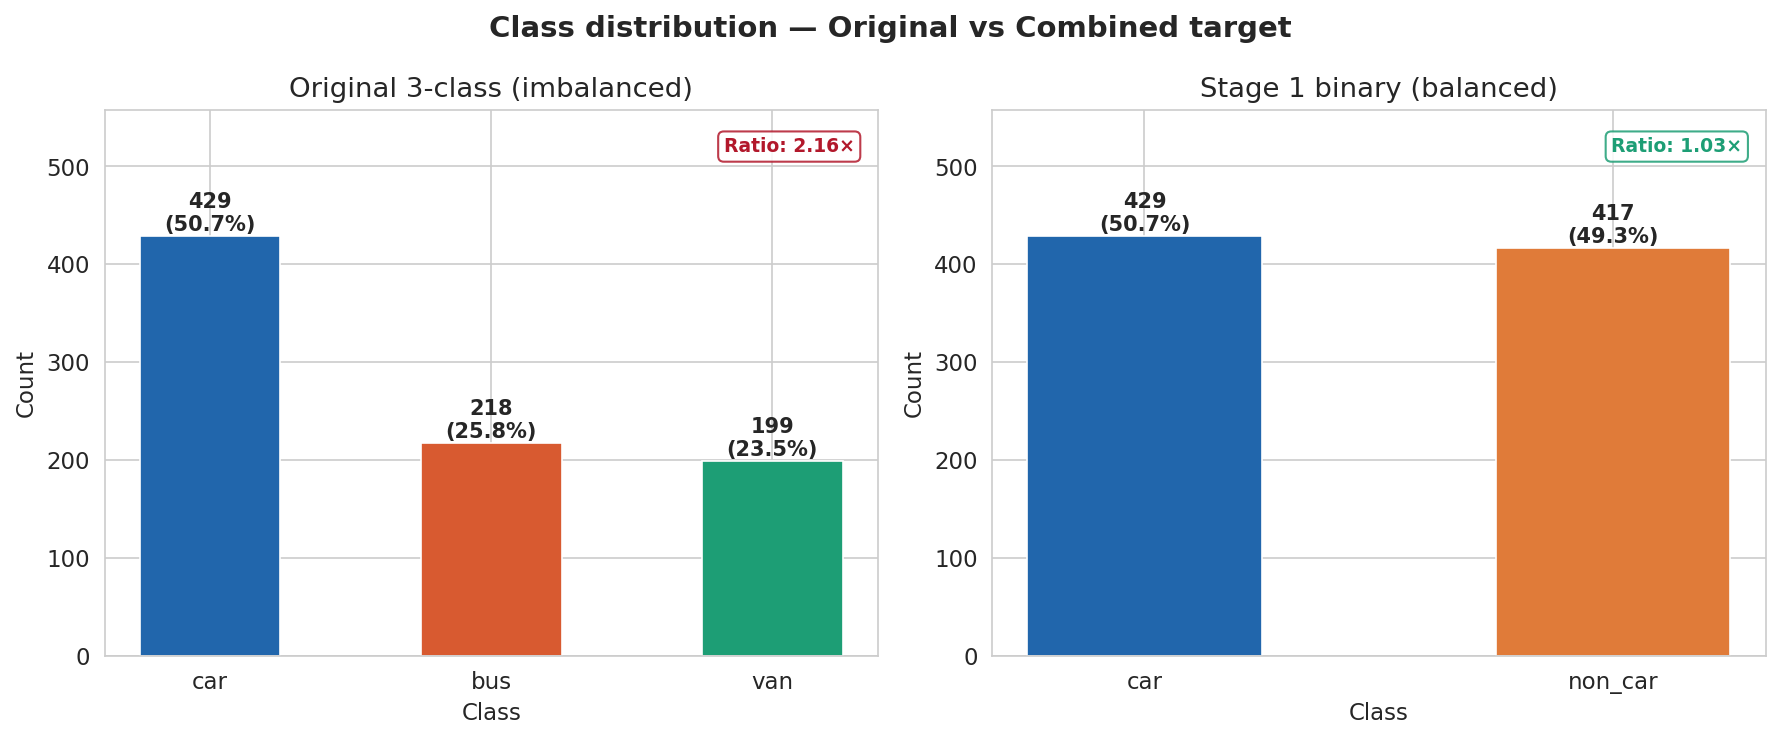

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_dat, title, palette in [
    (axes[0], y_orig, 'Original 3-class (imbalanced)',
     ['#2166AC', '#D85A30', '#1D9E75']),
    (axes[1], y_s1,   'Stage 1 binary (balanced)',
     ['#2166AC', '#E07B39']),
]:
    vc   = y_dat.value_counts()
    bars = ax.bar(vc.index, vc.values, color=palette,
                  edgecolor='white', linewidth=0.8, width=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(y_dat)*100:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
    ratio = vc.max() / vc.min()
    col   = '#B2182B' if ratio > 1.5 else '#1D9E75'
    ax.text(0.97, 0.95, f'Ratio: {ratio:.2f}×',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=col, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.85))
    ax.set(title=title, xlabel='Class', ylabel='Count')
    ax.set_ylim(0, vc.max() * 1.3)

plt.suptitle('Class distribution — Original vs Combined target',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('fig01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: fig01_class_distribution.png")

### Figure 2: Pipeline architecture

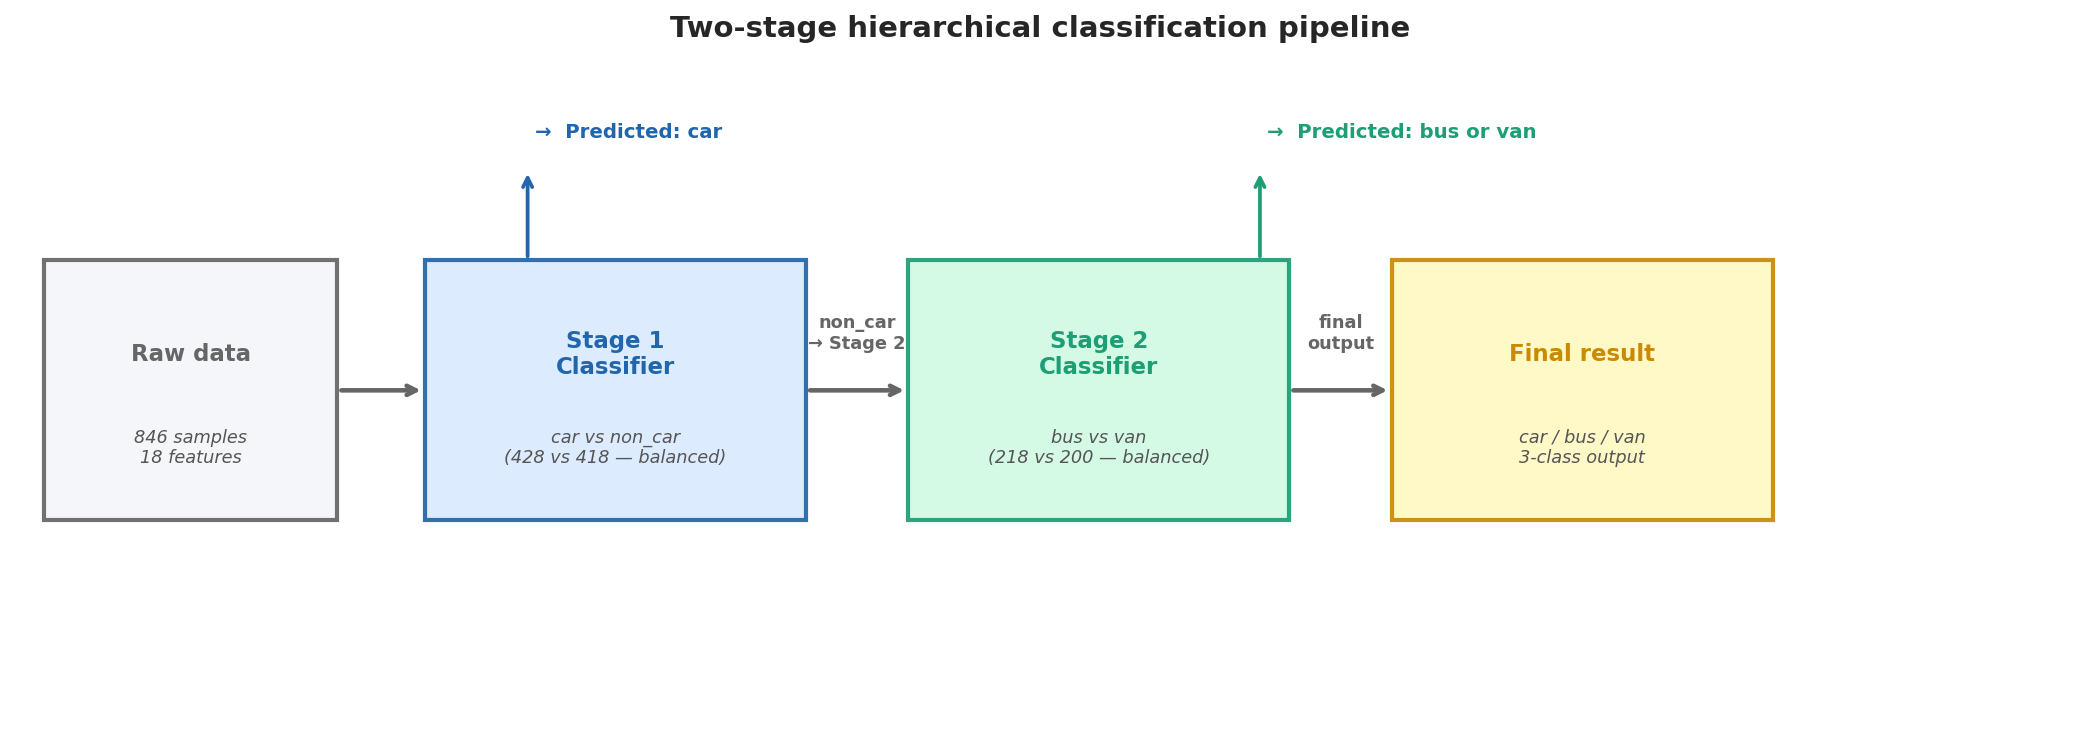

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14); ax.set_ylim(0, 5); ax.axis('off')

def pbox(ax, x, y, w, h, title, sub, fc, ec, fs=11):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec=ec,
                                lw=2, zorder=3, alpha=0.93))
    ax.text(x + w/2, y + h*0.64, title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=ec, zorder=4)
    ax.text(x + w/2, y + h*0.28, sub, ha='center', va='center',
            fontsize=8.5, color='#555', zorder=4, style='italic')

def parrow(ax, x1, x2, y=2.5, color='#666', label=''):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    if label:
        ax.text((x1+x2)/2, y+0.32, label, ha='center',
                fontsize=8.5, color=color, fontweight='bold')

pbox(ax, 0.2, 1.5, 2.0, 2.0, 'Raw data',
     '846 samples\n18 features', '#F4F6F9', '#666')
parrow(ax, 2.2, 2.8)
pbox(ax, 2.8, 1.5, 2.6, 2.0, 'Stage 1\nClassifier',
     'car vs non_car\n(428 vs 418 — balanced)', '#DBEAFE', '#2166AC')
ax.annotate('', xy=(3.5, 4.2), xytext=(3.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='#2166AC', lw=1.8))
ax.text(3.55, 4.45, '→  Predicted: car', fontsize=9.5,
        color='#2166AC', fontweight='bold')
parrow(ax, 5.4, 6.1, label='non_car\n→ Stage 2')
pbox(ax, 6.1, 1.5, 2.6, 2.0, 'Stage 2\nClassifier',
     'bus vs van\n(218 vs 200 — balanced)', '#D1FAE5', '#1D9E75')
ax.annotate('', xy=(8.5, 4.2), xytext=(8.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.8))
ax.text(8.55, 4.45, '→  Predicted: bus or van', fontsize=9.5,
        color='#1D9E75', fontweight='bold')
parrow(ax, 8.7, 9.4, label='final\noutput')
pbox(ax, 9.4, 1.5, 2.6, 2.0, 'Final result',
     'car / bus / van\n3-class output', '#FEF9C3', '#CA8A04')

ax.set_title('Two-stage hierarchical classification pipeline',
             fontweight='bold', fontsize=14, pad=14)
plt.tight_layout()
plt.savefig('fig02_pipeline_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: fig02_pipeline_architecture.png")

###  Figure 3: Stage 1 feature distributions (KDE)

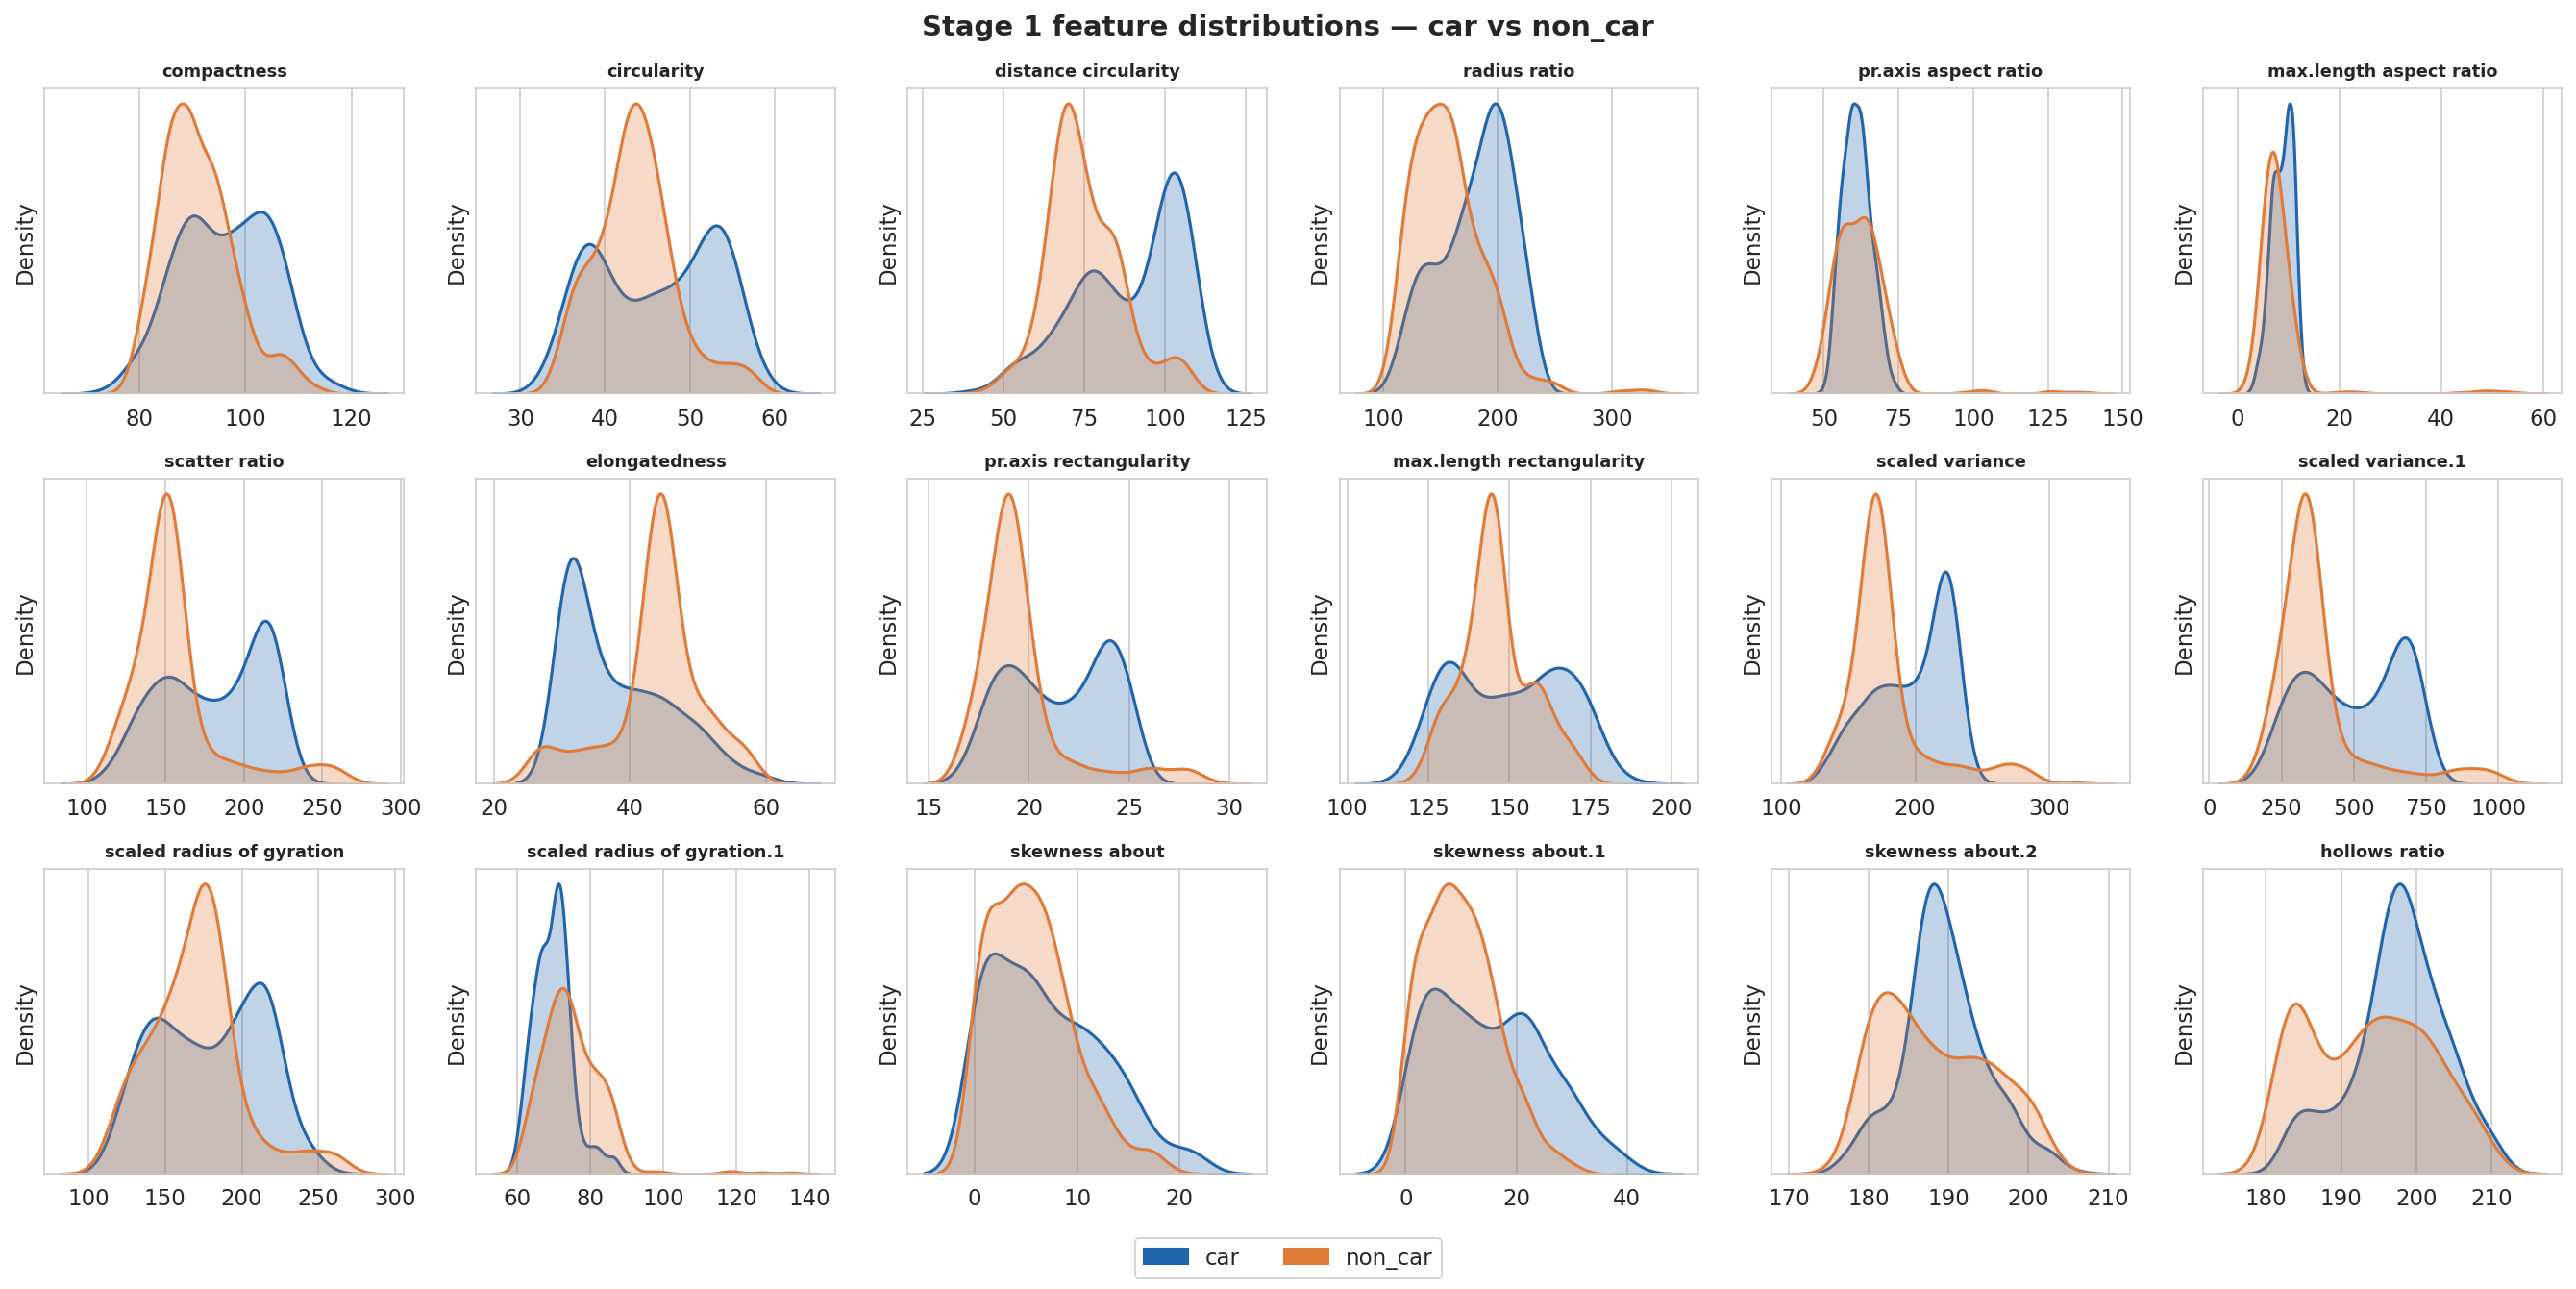

In [12]:
df['s1'] = y_s1
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax, feat in zip(axes.flatten(), features):
    for cls, col in P_S1.items():
        sns.kdeplot(df[df.s1 == cls][feat], ax=ax, color=col,
                    label=cls, fill=True, alpha=0.28, linewidth=1.5)
    ax.set_title(feat.replace('_', ' '), fontsize=8.5, fontweight='bold')
    ax.set_xlabel(''); ax.set_yticks([])
patches = [mpatches.Patch(color=col, label=cls) for cls, col in P_S1.items()]
fig.legend(handles=patches, loc='lower center', ncol=2, fontsize=11)
fig.suptitle('Stage 1 feature distributions — car vs non_car',
             fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0.04, 1, 1])
#plt.savefig('fig03_stage1_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: fig03_stage1_feature_distributions.png")

### Figure 4: Stage 2 feature distributions (KDE)

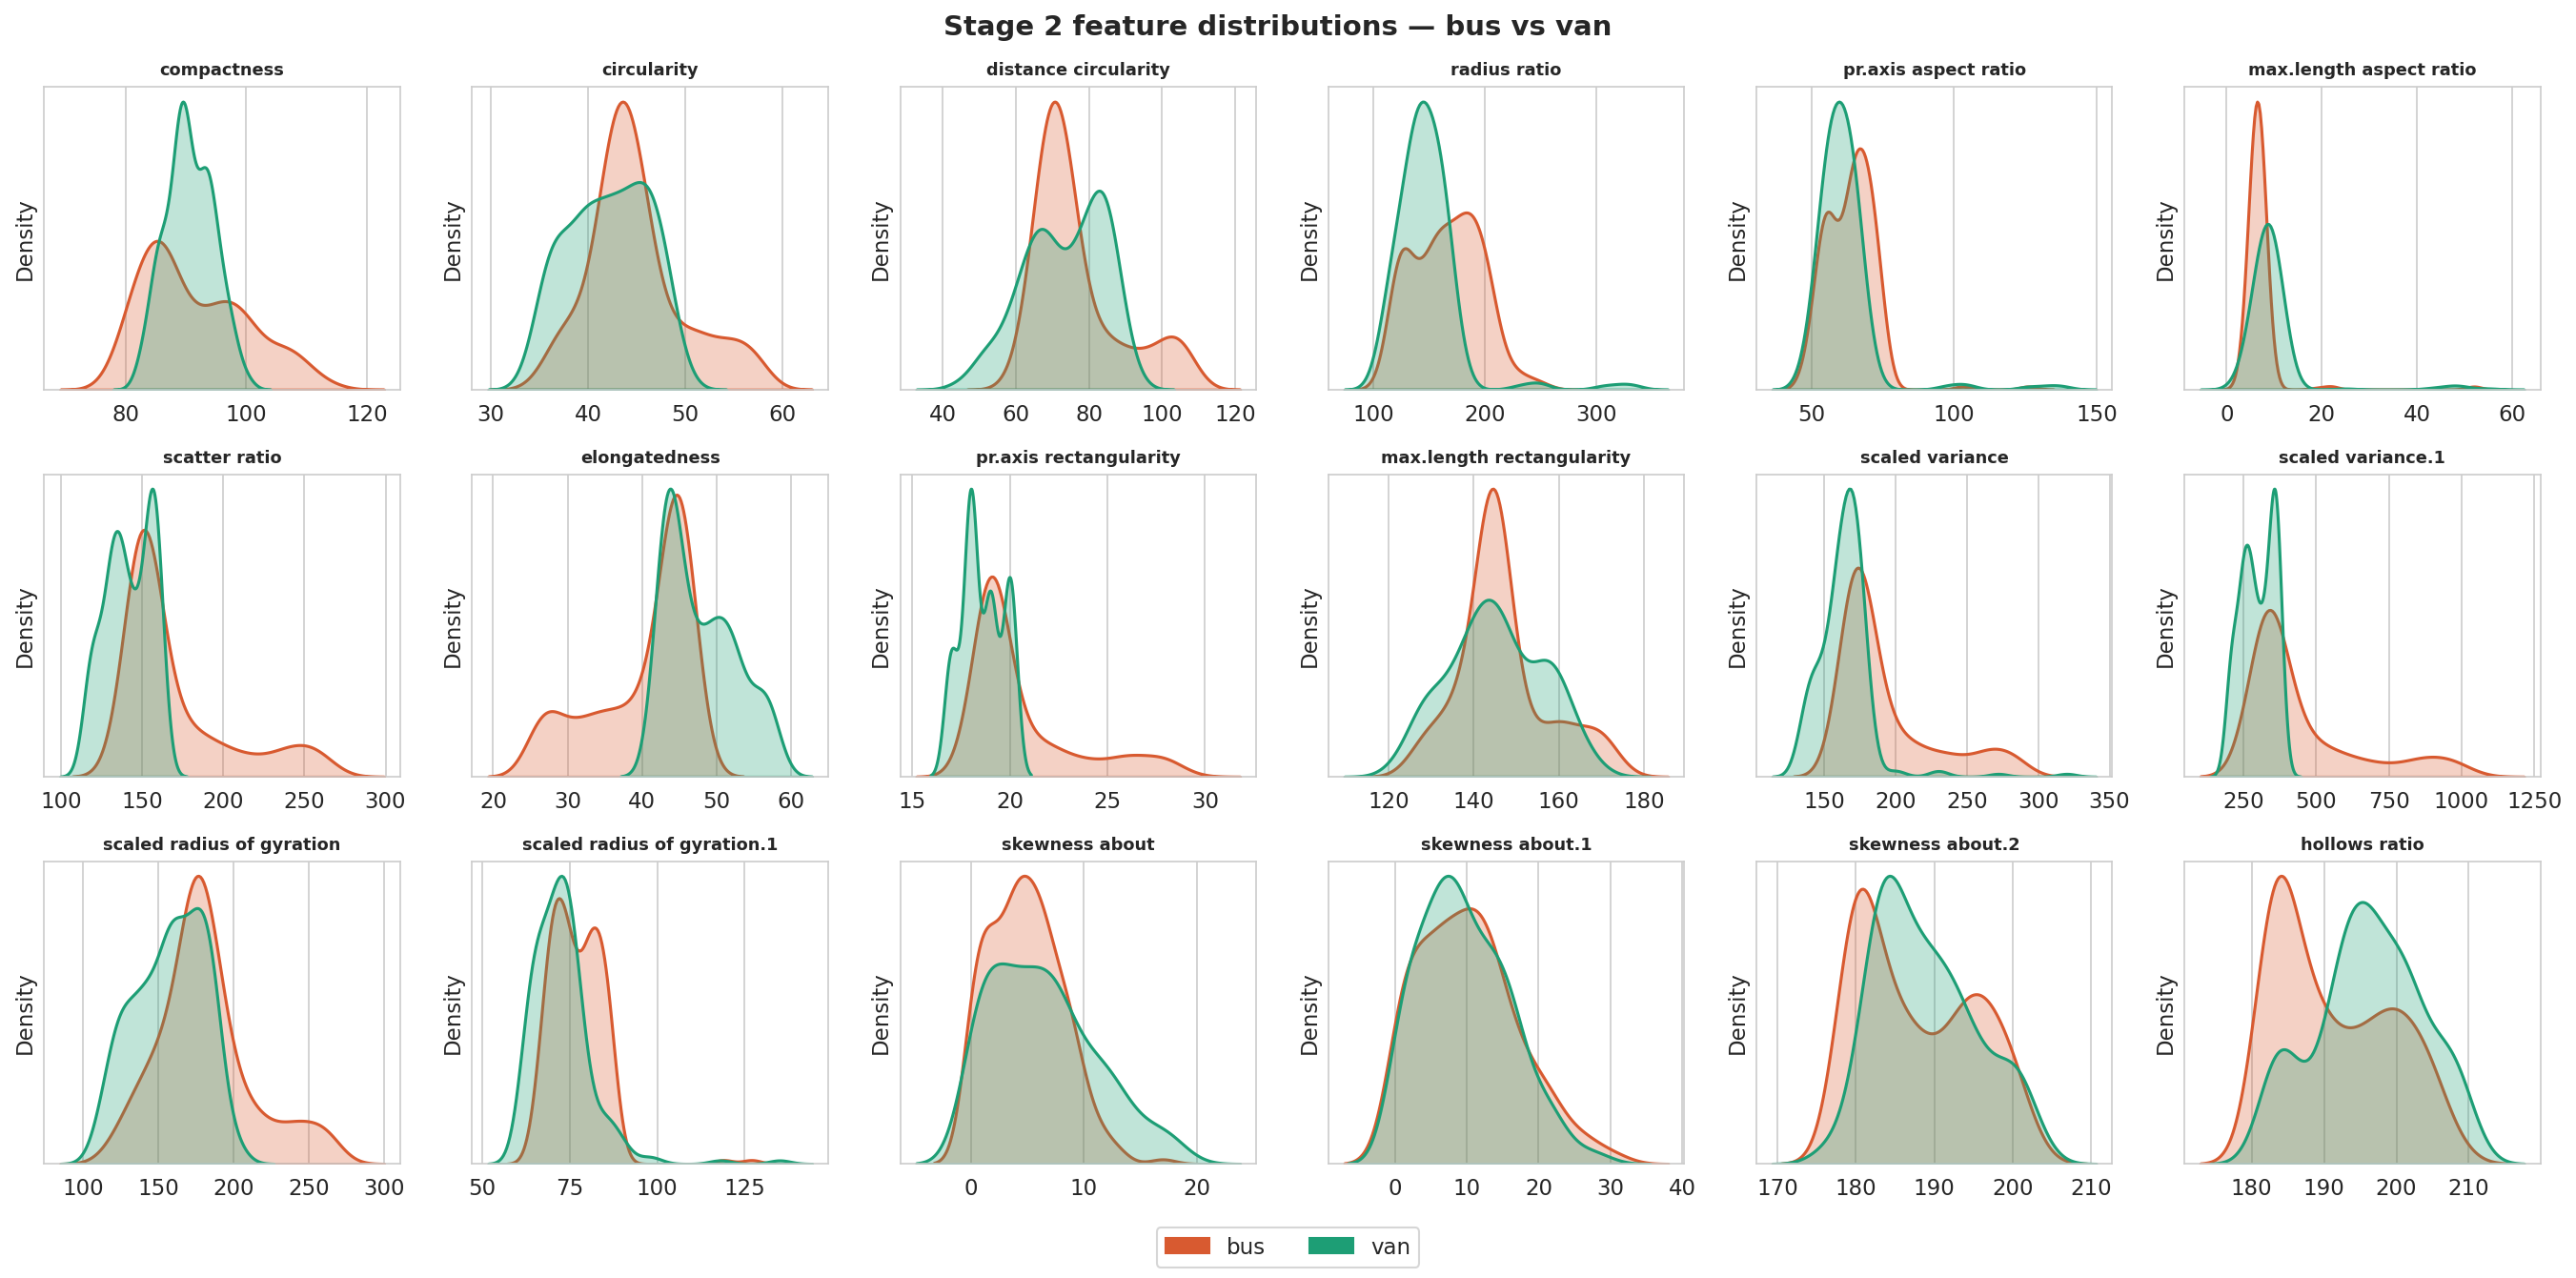

In [13]:
df_nc = df[df['target'] != 'car'].copy()
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for ax, feat in zip(axes.flatten(), features):
    for cls, col in P_S2.items():
        sns.kdeplot(df_nc[df_nc.target == cls][feat], ax=ax, color=col,
                    label=cls, fill=True, alpha=0.28, linewidth=1.5)
    ax.set_title(feat.replace('_', ' '), fontsize=8.5, fontweight='bold')
    ax.set_xlabel(''); ax.set_yticks([])
patches2 = [mpatches.Patch(color=col, label=cls) for cls, col in P_S2.items()]
fig.legend(handles=patches2, loc='lower center', ncol=2, fontsize=11)
fig.suptitle('Stage 2 feature distributions — bus vs van',
             fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0.04, 1, 1])
#plt.savefig('fig04_stage2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: fig04_stage2_feature_distributions.png")

### Figure 5: Heatmap `all features`


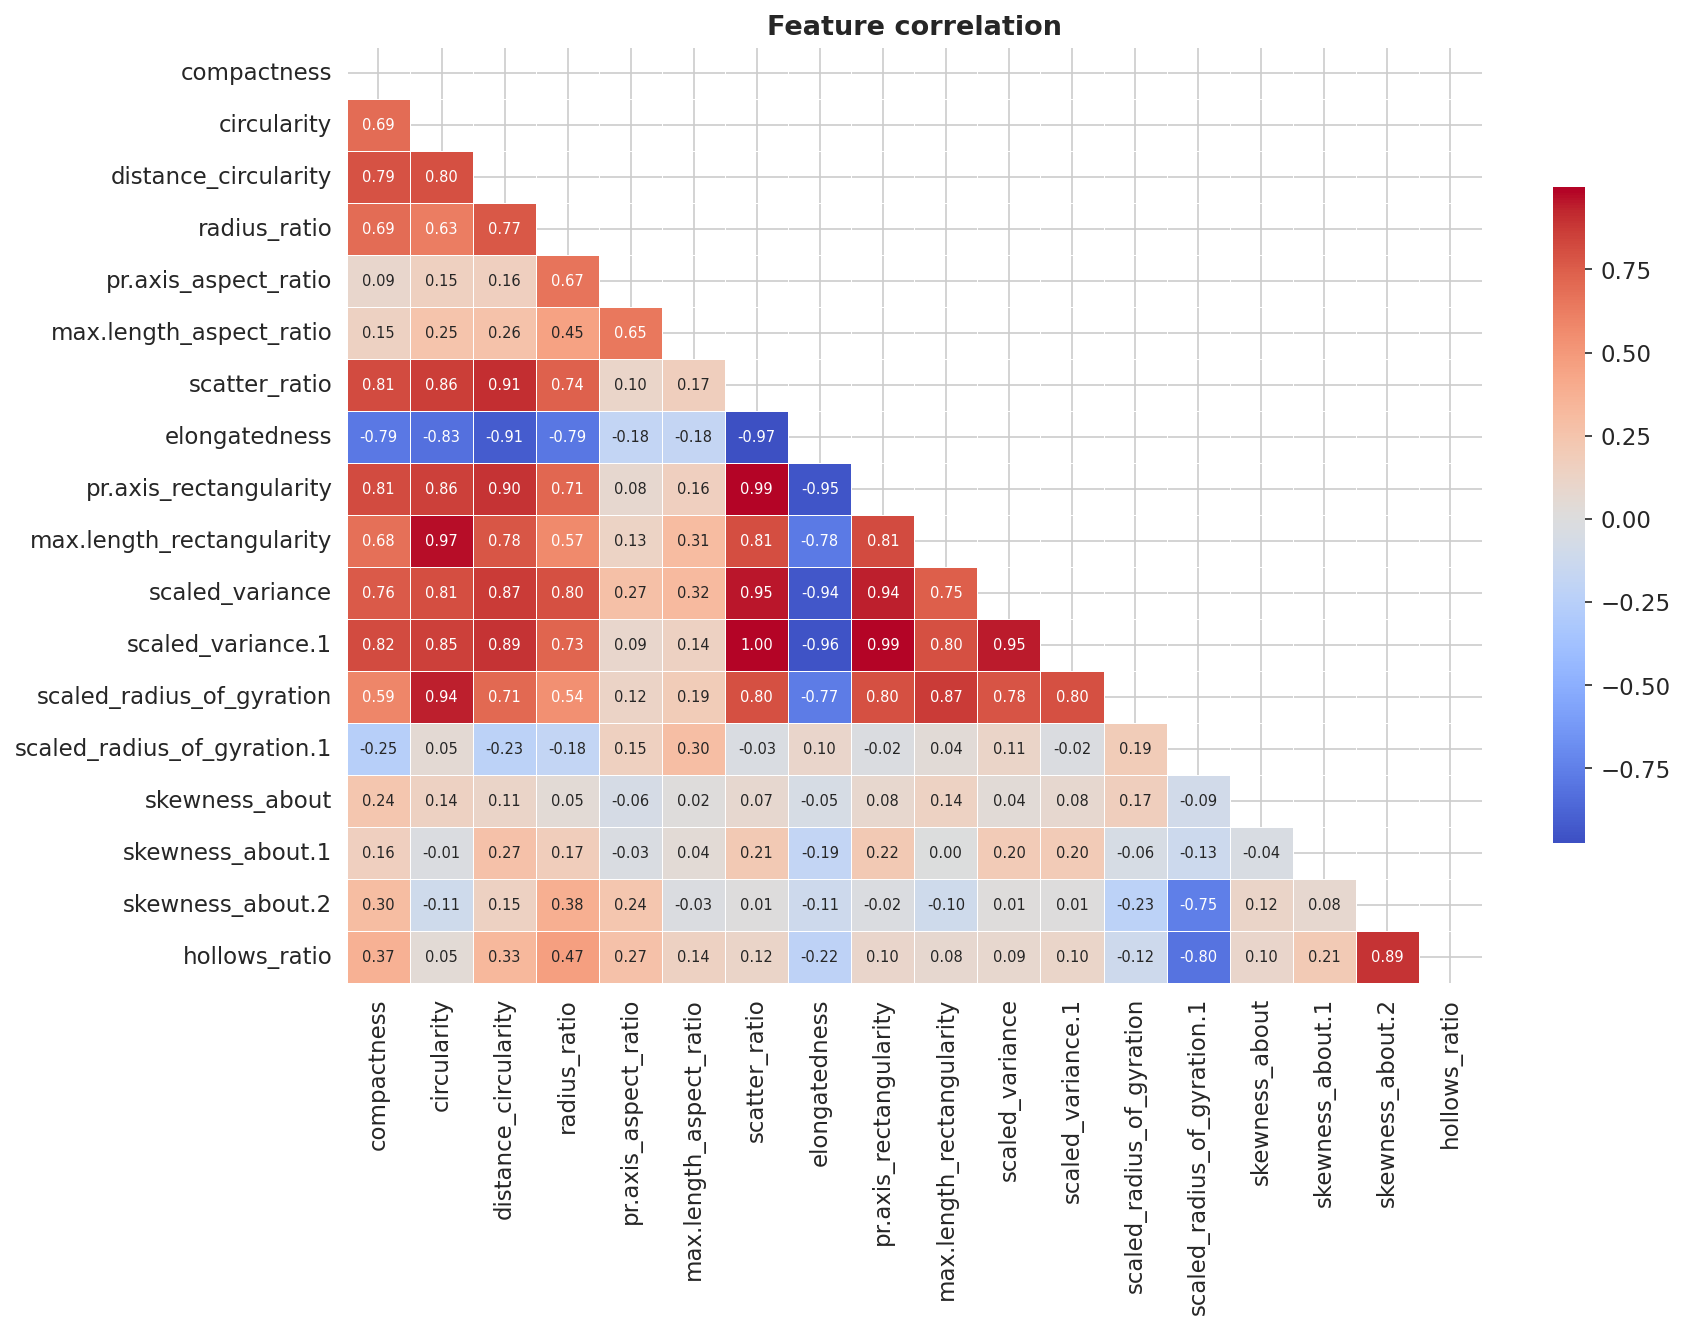

In [14]:
# Create the correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig02.1_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 6: Heatmap `dropping correlated features`


In [15]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df = df.drop(columns=to_drop)

In [16]:
# Update features and X_all after dropping correlated columns
features = [c for c in df.columns if c not in ['target', 's1']]
X_all    = df[features].values
y_orig   = df['target'].values

print(f"\nUpdated features: {len(features)}")
print(f"X_all shape: {X_all.shape}")


Updated features: 11
X_all shape: (846, 11)


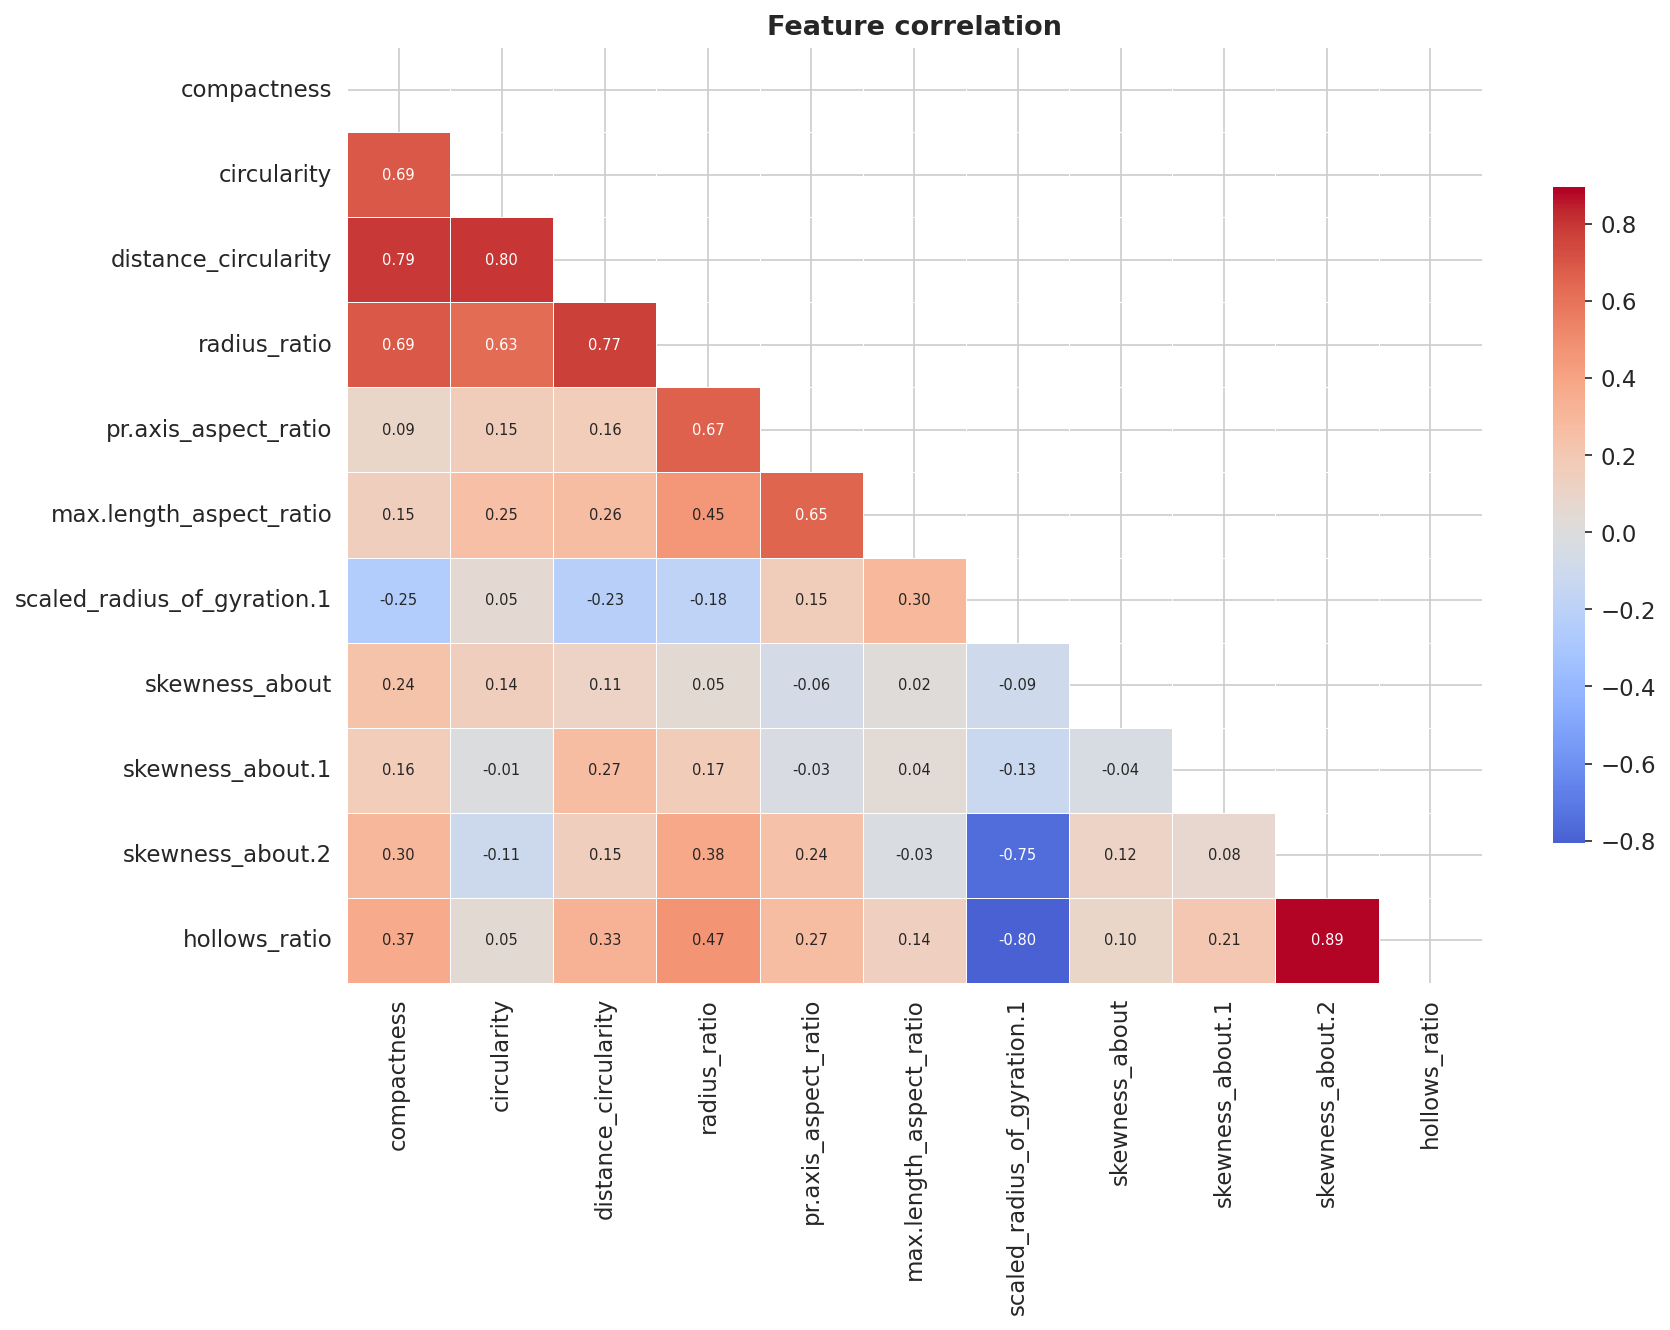

In [17]:
# Create the correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
ax.set_title('Feature correlation', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig02.2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing

## Three-Way Split  `(65 / 15 / 20)`


Step 1 — 20 % test set

In [18]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_orig,
    test_size=0.20, random_state=42, stratify=y_orig)

Step 2 —  Remainder split into 65 % train + 15 % validation (0.19 of 80 % = 15 % of total)



In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.19, random_state=42,
    stratify=y_temp)

n_tr, n_va, n_te = len(X_train), len(X_val), len(X_test)
n_total = n_tr + n_va + n_te

In [20]:
print(f"\nData split (65 / 15 / 20):")
print(f"  Train      : {n_tr:4d} samples  ({n_tr/n_total*100:.0f} %)")
print(f"  Validation : {n_va:4d} samples  ({n_va/n_total*100:.0f} %)")
print(f"  Test       : {n_te:4d} samples  ({n_te/n_total*100:.0f} %)")


Data split (65 / 15 / 20):
  Train      :  547 samples  (65 %)
  Validation :  129 samples  (15 %)
  Test       :  170 samples  (20 %)


## Impute Missing Values (Median)

In [21]:
from sklearn.impute import SimpleImputer

# Impute missing values using the median strategy
imputer = SimpleImputer(strategy='median')

# Fit on training data and transform all splits
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

print("Missing values imputed using median strategy.")

Missing values imputed using median strategy.


In [22]:
imputed_df_head = pd.DataFrame(X_train[:5], columns=features)
imputed_df_head.isna().sum().sum()

np.int64(0)

# Stage 1 - Target  (car vs non_car)

In [23]:
def to_stage1(y):
   return np.where(y == 'car', 'car', 'non_car')

y_train_stage1 = to_stage1(y_train)
y_val_stage1   = to_stage1(y_val)
y_test_stage1  = to_stage1(y_test)

print(f"\nStage 1 class balance:")
for split, y_ in [('Train', y_train_stage1),('Val', y_val_stage1),('Test', y_test_stage1)]:
    u, c = np.unique(y_, return_counts=True)
    ratio = c.max()/c.min()
    print(f"  {split:5s}: {dict(zip(u,c))}  ratio={ratio:.2f}x")


Stage 1 class balance:
  Train: {np.str_('car'): np.int64(277), np.str_('non_car'): np.int64(270)}  ratio=1.03x
  Val  : {np.str_('car'): np.int64(66), np.str_('non_car'): np.int64(63)}  ratio=1.05x
  Test : {np.str_('car'): np.int64(86), np.str_('non_car'): np.int64(84)}  ratio=1.02x


### Stage 1: Fit scalers on train set `(avoid leakage)`


In [24]:
scaler1 = StandardScaler().fit(X_train)
X_tr1   = scaler1.transform(X_train)
X_va1   = scaler1.transform(X_val)
X_te1   = scaler1.transform(X_test)

# Stage - 2: non-car (bus vs van)

### Stage 2: fit scalers on train set `(avoid leakage)`


In [25]:
nc_tr   = y_train != 'car'
nc_va   = y_val   != 'car'
nc_te   = y_test  != 'car'

scaler2 = StandardScaler().fit(X_train[nc_tr])
X_tr2   = scaler2.transform(X_train[nc_tr]);  y_tr2 = y_train[nc_tr]
X_va2   = scaler2.transform(X_val[nc_va]);    y_va2 = y_val[nc_va]
X_te2   = scaler2.transform(X_test[nc_te]);   y_te2 = y_test[nc_te]

print(f"\nStage 2 samples (bus+van only):")
print(f"  Train: {len(X_tr2)}  Val: {len(X_va2)}  Test: {len(X_te2)}")


Stage 2 samples (bus+van only):
  Train: 270  Val: 63  Test: 84


# Defining Classification models

In [26]:
def make_models():
    return {
        'Logistic Reg.':     LogisticRegression(C=1.0, max_iter=1000, random_state=42),
        'Decision Tree':     DecisionTreeClassifier(max_depth=8, random_state=42),
        'Random Forest':     RandomForestClassifier(n_estimators=200,
                                                    class_weight='balanced',
                                                    random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                        learning_rate=0.1,
                                                        random_state=42),
        'SVM':               SVC(C=10, kernel='rbf', probability=True, random_state=42),
        'KNN':               KNeighborsClassifier(n_neighbors=7),
    }


# Training and Evaluation (train / val / test)

### Defining the evaluation metrics

In [27]:
def compute_metrics(model, X, y, y_ref):
    yp  = model.predict(X)
    ypr = model.predict_proba(X)
    classes = sorted(np.unique(np.concatenate([y_ref, y])))
    yb = label_binarize(y, classes=classes)
    try:
        if yb.shape[1] == 1:          # binary
            ra = roc_auc_score(yb, ypr[:, 1])
        else:
            ra = roc_auc_score(yb, ypr, multi_class='ovr', average='macro')
    except Exception:
        ra = np.nan
    return {
        'y_pred':   yp,
        'y_prob':   ypr,
        'macro_f1': f1_score(y, yp, average='macro'),
        'auc':      ra,
    }

### Crosss validation parameters for Stage 1 and Stage 2

In [28]:
skf1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Evaluating a single model

In [29]:
def evaluate_single_model(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, skf):
    model.fit(X_tr, y_tr)

    train_metrics = compute_metrics(model, X_tr, y_tr, y_tr)
    val_metrics   = compute_metrics(model, X_va, y_va, y_tr)
    test_metrics  = compute_metrics(model, X_te, y_te, y_tr)

    cv = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1_macro')

    return {
        'model':   model,
        'train':   train_metrics,
        'val':     val_metrics,
        'test':    test_metrics,
        'cv_mean': cv.mean(),
        'cv_std':  cv.std(),
    }

### Evaluate all models

In [30]:
def evaluate_models(X_tr, y_tr, X_va, y_va, X_te, y_te, skf):
    results = {}

    for name, model in make_models().items():
        results[name] = evaluate_single_model(
            name, model,
            X_tr, y_tr,
            X_va, y_va,
            X_te, y_te,
            skf
        )

    return results

## Choosing the best model based on the F1-score

# Run Stage 1: (car vs non_car)

In [31]:
print("STAGE 1 — car vs non_car")
print("-" * 65)
res_stage1 = evaluate_models(X_tr1, y_train_stage1, X_va1, y_val_stage1,
                        X_te1, y_test_stage1,  skf1)
for name, r in res_stage1.items():
    print(f"  {name:22s} | Train={r['train']['macro_f1']:.3f} "
          f"Val={r['val']['macro_f1']:.3f} "
          f"Test={r['test']['macro_f1']:.3f} "
          f"CV={r['cv_mean']:.3f}±{r['cv_std']:.3f}")

STAGE 1 — car vs non_car
-----------------------------------------------------------------
  Logistic Reg.          | Train=0.929 Val=0.922 Test=0.912 CV=0.929±0.013
  Decision Tree          | Train=0.963 Val=0.860 Test=0.824 CV=0.879±0.034
  Random Forest          | Train=1.000 Val=0.946 Test=0.935 CV=0.925±0.026
  Gradient Boosting      | Train=1.000 Val=0.922 Test=0.929 CV=0.940±0.019
  SVM                    | Train=0.991 Val=0.946 Test=0.965 CV=0.969±0.020
  KNN                    | Train=0.940 Val=0.899 Test=0.912 CV=0.899±0.019


## Confusion Matrix for Stage 1 (Car vs Non-Car)


**Train / Val / Test**
*   Accuracy
*   Precision
*   Recal
*   F1-Score






In [32]:
print("STAGE 1 — CONFUSION MATRICES (TRAIN / VAL / TEST)")
print("-" * 70)

for name, r in res_stage1.items():

    print(f"\n\n🔹 {name}")
    print("-" * 20)

    # ---------------- TRAIN ----------------
    cm_tr = confusion_matrix(y_train_stage1, r['train']['y_pred'])
    acc_tr = accuracy_score(y_train_stage1, r['train']['y_pred'])
    prec_tr = precision_score(y_train_stage1, r['train']['y_pred'], pos_label='car')
    rec_tr = recall_score(y_train_stage1, r['train']['y_pred'], pos_label='car')
    f1_tr = f1_score(y_train_stage1, r['train']['y_pred'], average='macro')

    print("\n--TRAIN--")
    print(cm_tr)
    print(f"Accuracy : {acc_tr:.3f} | Precision: {prec_tr:.3f} | Recall: {rec_tr:.3f}")

    # ---------------- VALIDATION ----------------
    cm_va = confusion_matrix(y_val_stage1, r['val']['y_pred'])
    acc_va = accuracy_score(y_val_stage1, r['val']['y_pred'])
    prec_va = precision_score(y_val_stage1, r['val']['y_pred'], pos_label='car')
    rec_va = recall_score(y_val_stage1, r['val']['y_pred'], pos_label='car')
    f1_va = f1_score(y_val_stage1, r['val']['y_pred'], average='macro')

    print("\n--VALIDATION--")
    print(cm_va)
    print(f"Accuracy : {acc_va:.3f} | Precision: {prec_va:.3f} | Recall: {rec_va:.3f}")

    # ---------------- TEST ----------------
    cm_te = confusion_matrix(y_test_stage1, r['test']['y_pred'])
    acc_te = accuracy_score(y_test_stage1, r['test']['y_pred'])
    prec_te = precision_score(y_test_stage1, r['test']['y_pred'], pos_label='car')
    rec_te = recall_score(y_test_stage1, r['test']['y_pred'], pos_label='car')
    f1_te = f1_score(y_test_stage1, r['test']['y_pred'], average='macro')

    print("\n--TEST--")
    print(cm_te)
    print(f"Accuracy : {acc_te:.3f} | Precision: {prec_te:.3f} | Recall: {rec_te:.3f}")

STAGE 1 — CONFUSION MATRICES (TRAIN / VAL / TEST)
----------------------------------------------------------------------


🔹 Logistic Reg.
--------------------

--TRAIN--
[[256  21]
 [ 18 252]]
Accuracy : 0.929 | Precision: 0.934 | Recall: 0.924

--VALIDATION--
[[60  6]
 [ 4 59]]
Accuracy : 0.922 | Precision: 0.938 | Recall: 0.909

--TEST--
[[74 12]
 [ 3 81]]
Accuracy : 0.912 | Precision: 0.961 | Recall: 0.860


🔹 Decision Tree
--------------------

--TRAIN--
[[265  12]
 [  8 262]]
Accuracy : 0.963 | Precision: 0.971 | Recall: 0.957

--VALIDATION--
[[56 10]
 [ 8 55]]
Accuracy : 0.860 | Precision: 0.875 | Recall: 0.848

--TEST--
[[69 17]
 [13 71]]
Accuracy : 0.824 | Precision: 0.841 | Recall: 0.802


🔹 Random Forest
--------------------

--TRAIN--
[[277   0]
 [  0 270]]
Accuracy : 1.000 | Precision: 1.000 | Recall: 1.000

--VALIDATION--
[[61  5]
 [ 2 61]]
Accuracy : 0.946 | Precision: 0.968 | Recall: 0.924

--TEST--
[[78  8]
 [ 3 81]]
Accuracy : 0.935 | Precision: 0.963 | Recall: 0.907


# Run Stage 2:  Bus vs Van

In [33]:
print("STAGE 2 — bus vs van")
print("-" * 65)
res_stage2 = evaluate_models(X_tr2, y_tr2, X_va2, y_va2, X_te2, y_te2, skf2)
for name, r in res_stage2.items():
    print(f"  {name:22s} | Train={r['train']['macro_f1']:.3f} "
          f"Val={r['val']['macro_f1']:.3f} "
          f"Test={r['test']['macro_f1']:.3f} "
          f"CV={r['cv_mean']:.3f}±{r['cv_std']:.3f}")

STAGE 2 — bus vs van
-----------------------------------------------------------------
  Logistic Reg.          | Train=0.918 Val=0.920 Test=0.940 CV=0.907±0.035
  Decision Tree          | Train=1.000 Val=0.887 Test=0.928 CV=0.903±0.027
  Random Forest          | Train=1.000 Val=0.984 Test=0.976 CV=0.967±0.014
  Gradient Boosting      | Train=1.000 Val=0.968 Test=0.964 CV=0.955±0.019
  SVM                    | Train=0.985 Val=0.968 Test=0.964 CV=0.944±0.026
  KNN                    | Train=0.940 Val=0.920 Test=0.964 CV=0.899±0.034


## Confusion Matrix for Stage 2 (Bus vs Van)


**Train / Val / Test**
*   Accuracy
*   Precision
*   Recal
*   F1-Score


In [34]:
print("STAGE 2 — CONFUSION MATRICES (TRAIN / VAL / TEST)")
print("-" * 70)

for name, r in res_stage2.items():

    print(f"\n\n🔹 {name}")
    print("-" * 20)

    # ---------------- TRAIN ----------------
    cm_tr = confusion_matrix(y_tr2, r['train']['y_pred'])
    acc_tr = accuracy_score(y_tr2, r['train']['y_pred'])
    prec_tr = precision_score(y_tr2, r['train']['y_pred'], pos_label='bus')
    rec_tr = recall_score(y_tr2, r['train']['y_pred'], pos_label='bus')
    f2_tr = f1_score(y_tr2, r['train']['y_pred'], average='macro')

    print("\n--TRAIN--")
    print(cm_tr)
    print(f"Accuracy : {acc_tr:.3f} | Precision: {prec_tr:.3f} | Recall: {rec_tr:.3f}")

    # ---------------- VALIDATION ----------------
    cm_va = confusion_matrix(y_va2, r['val']['y_pred'])
    acc_va = accuracy_score(y_va2, r['val']['y_pred'])
    prec_va = precision_score(y_va2, r['val']['y_pred'], pos_label='bus')
    rec_va = recall_score(y_va2, r['val']['y_pred'], pos_label='bus')
    f2_va = f1_score(y_va2, r['val']['y_pred'], average='macro')

    print("\n--VALIDATION--")
    print(cm_va)
    print(f"Accuracy : {acc_va:.3f} | Precision: {prec_va:.3f} | Recall: {rec_va:.3f}")

    # ---------------- TEST ----------------
    cm_te = confusion_matrix(y_te2, r['test']['y_pred'])
    acc_te = accuracy_score(y_te2, r['test']['y_pred'])
    prec_te = precision_score(y_te2, r['test']['y_pred'], pos_label='bus')
    rec_te = recall_score(y_te2, r['test']['y_pred'], pos_label='bus')
    f2_te = f1_score(y_te2, r['test']['y_pred'], average='macro')

    print("\n--TEST--")
    print(cm_te)
    print(f"Accuracy : {acc_te:.3f} | Precision: {prec_te:.3f} | Recall: {rec_te:.3f}")

STAGE 2 — CONFUSION MATRICES (TRAIN / VAL / TEST)
----------------------------------------------------------------------


🔹 Logistic Reg.
--------------------

--TRAIN--
[[127  14]
 [  8 121]]
Accuracy : 0.919 | Precision: 0.941 | Recall: 0.901

--VALIDATION--
[[32  1]
 [ 4 26]]
Accuracy : 0.921 | Precision: 0.889 | Recall: 0.970

--TEST--
[[42  2]
 [ 3 37]]
Accuracy : 0.940 | Precision: 0.933 | Recall: 0.955


🔹 Decision Tree
--------------------

--TRAIN--
[[141   0]
 [  0 129]]
Accuracy : 1.000 | Precision: 1.000 | Recall: 1.000

--VALIDATION--
[[32  1]
 [ 6 24]]
Accuracy : 0.889 | Precision: 0.842 | Recall: 0.970

--TEST--
[[43  1]
 [ 5 35]]
Accuracy : 0.929 | Precision: 0.896 | Recall: 0.977


🔹 Random Forest
--------------------

--TRAIN--
[[141   0]
 [  0 129]]
Accuracy : 1.000 | Precision: 1.000 | Recall: 1.000

--VALIDATION--
[[33  0]
 [ 1 29]]
Accuracy : 0.984 | Precision: 0.971 | Recall: 1.000

--TEST--
[[44  0]
 [ 2 38]]
Accuracy : 0.976 | Precision: 0.957 | Recall: 1.000


# Model selection (Stage1 and Stage 2) based on `Macro F1-Score`


In [35]:
best_stage1 = max(res_stage1, key=lambda m: res_stage1[m]['val']['macro_f1'])
print(f"\n  ★ Best Stage-1 model (by Val F1): {best_stage1}  "
      f"Val={res_stage1[best_stage1]['val']['macro_f1']:.4f}  "
      f"Test={res_stage1[best_stage1]['test']['macro_f1']:.4f}")

best_stage2 = max(res_stage2, key=lambda m: res_stage2[m]['val']['macro_f1'])
print(f"\n  ★ Best Stage-2 model (by Val F1): {best_stage2}  "
      f"Val={res_stage2[best_stage2]['val']['macro_f1']:.4f}  "
      f"Test={res_stage2[best_stage2]['test']['macro_f1']:.4f}")


  ★ Best Stage-1 model (by Val F1): Random Forest  Val=0.9457  Test=0.9353

  ★ Best Stage-2 model (by Val F1): Random Forest  Val=0.9841  Test=0.9761


# More Figures

## Fig 6: Data split visualisation

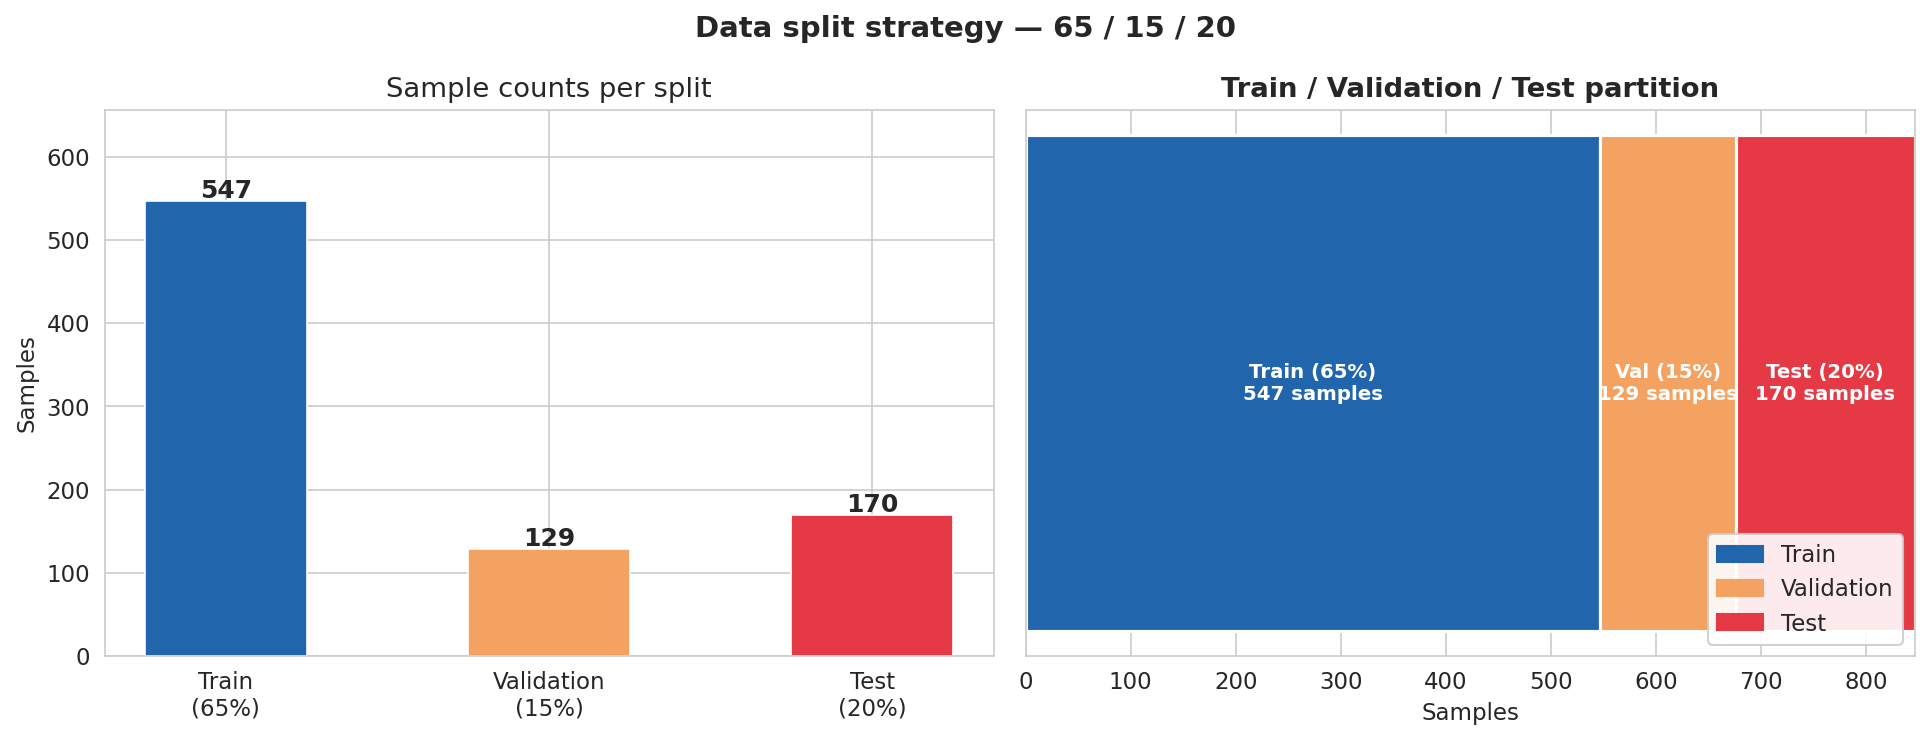

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar showing split sizes
splits = ['Train\n(65%)', 'Validation\n(15%)', 'Test\n(20%)']
sizes  = [n_tr, n_va, n_te]
cols   = [SPLIT_COLORS['Train'], SPLIT_COLORS['Validation'],
          SPLIT_COLORS['Test']]
bars   = axes[0].bar(splits, sizes, color=cols, edgecolor='white',
                     linewidth=0.8, width=0.5)
for bar, val in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].set(title='Sample counts per split', ylabel='Samples')
axes[0].set_ylim(0, max(sizes)*1.2)

# Right: horizontal proportional bar
left = 0
for label, size, col in zip(['Train (65%)', 'Val (15%)', 'Test (20%)'],
                              sizes, cols):
    axes[1].barh(0, size, left=left, color=col, edgecolor='white',
                 linewidth=1.5, height=0.4)
    axes[1].text(left + size/2, 0,
                 f'{label}\n{size} samples',
                 ha='center', va='center', fontsize=9.5,
                 fontweight='bold', color='white')
    left += size
axes[1].set_xlim(0, n_total)
axes[1].set_yticks([])
axes[1].set_xlabel('Samples')
axes[1].set_title('Train / Validation / Test partition', fontweight='bold')

# role annotations
for ax_idx, label, desc in [
    (1, 'Train: model fitting', '65% — used to fit all models'),
    (1, 'Validation: model selection', '15% — pick best model per stage'),
    (1, 'Test: final evaluation', '20% — unbiased final report'),
]:
    pass  # done via barh labels

patches = [mpatches.Patch(color=SPLIT_COLORS[k], label=k)
           for k in ['Train', 'Validation', 'Test']]
axes[1].legend(handles=patches, loc='lower right', framealpha=0.9)

plt.suptitle('Data split strategy — 65 / 15 / 20',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('fig6_data_split.png', dpi=150, bbox_inches='tight')
#plt.show(); print("Saved: fig06")

## Fig 7: Pipeline architecture

Text(10.35, 0.4, 'Val F1 → select best Stage 2 model')

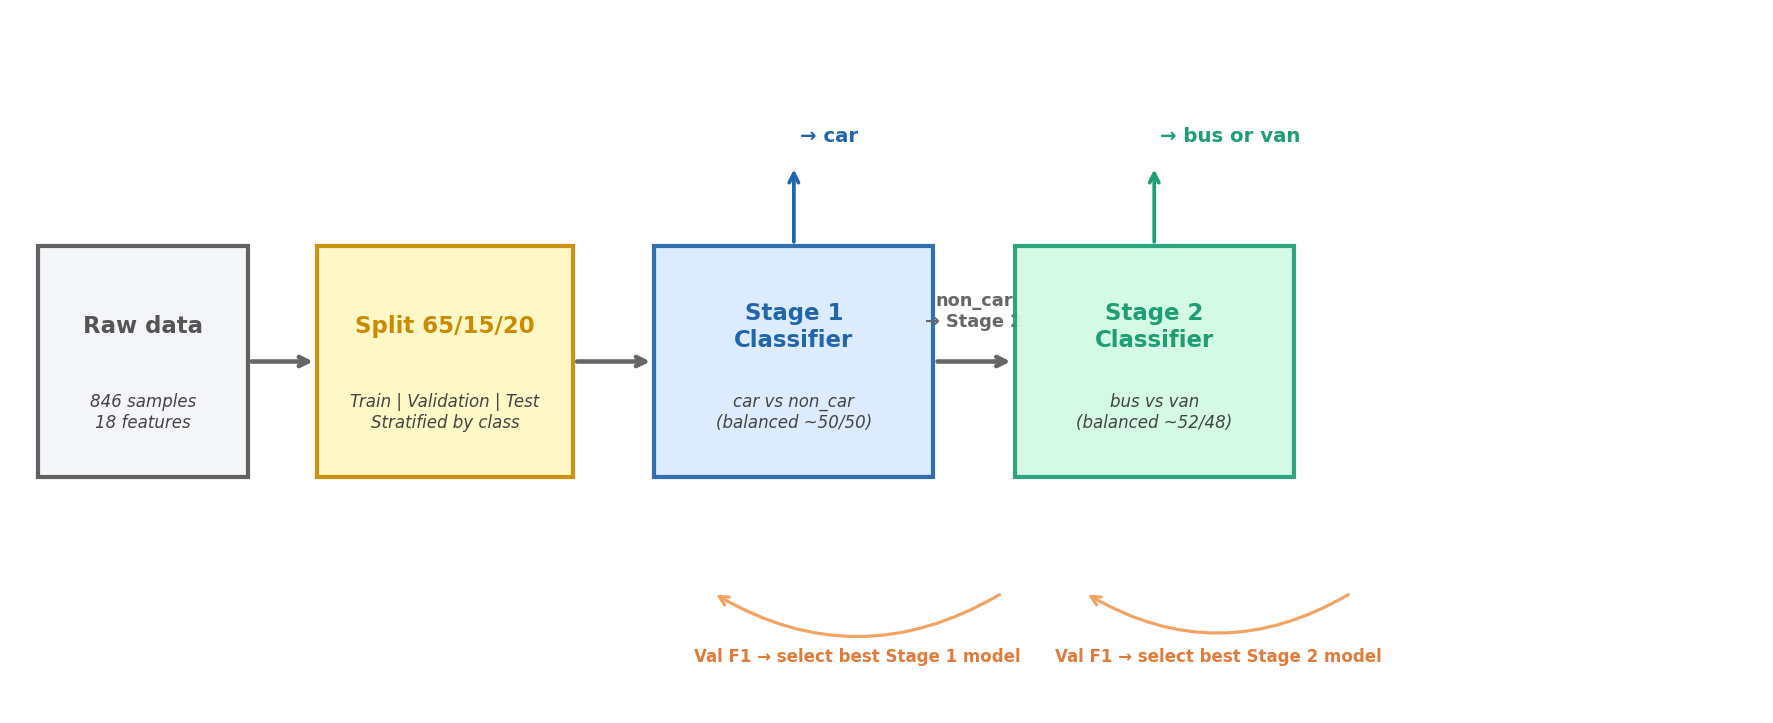

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 15); ax.set_ylim(0, 6); ax.axis('off')

def pbox(x, y, w, h, title, sub, fc, ec, fs=11):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc=fc, ec=ec,
                                lw=2, zorder=3, alpha=0.93))
    ax.text(x+w/2, y+h*0.65, title, ha='center', va='center',
            fontsize=fs, fontweight='bold', color=ec, zorder=4)
    ax.text(x+w/2, y+h*0.28, sub, ha='center', va='center',
            fontsize=8, color='#444', zorder=4, style='italic')

def parrow(x1, x2, y=3.0, color='#666', label=''):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))
    if label:
        ax.text((x1+x2)/2, y+0.3, label, ha='center',
                fontsize=8.5, color=color, fontweight='bold')

# Data box + split
pbox(0.2, 2.0, 1.8, 2.0, 'Raw data', '846 samples\n18 features',
     '#F4F6F9', '#555')
parrow(2.0, 2.6)
pbox(2.6, 2.0, 2.2, 2.0, 'Split 65/15/20',
     'Train | Validation | Test\nStratified by class', '#FEF9C3', '#CA8A04')

# Stage 1
parrow(4.8, 5.5)
pbox(5.5, 2.0, 2.4, 2.0, 'Stage 1\nClassifier',
     'car vs non_car\n(balanced ~50/50)', '#DBEAFE', '#2166AC')
# car branch
ax.annotate('', xy=(6.7, 4.7), xytext=(6.7, 4.0),
            arrowprops=dict(arrowstyle='->', color='#2166AC', lw=1.8))
ax.text(6.75, 4.9, '→ car', fontsize=9.5, color='#2166AC', fontweight='bold')

# Val feedback arrow Stage 1
ax.annotate('', xy=(6.0, 1.0), xytext=(8.5, 1.0),
            arrowprops=dict(arrowstyle='->', color='#F4A261', lw=1.5,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(7.25, 0.4, 'Val F1 → select best Stage 1 model',
        ha='center', fontsize=8, color='#E07B39', fontweight='bold')

# Stage 2
parrow(7.9, 8.6, label='non_car\n→ Stage 2')
pbox(8.6, 2.0, 2.4, 2.0, 'Stage 2\nClassifier',
     'bus vs van\n(balanced ~52/48)', '#D1FAE5', '#1D9E75')
ax.annotate('', xy=(9.8, 4.7), xytext=(9.8, 4.0),
            arrowprops=dict(arrowstyle='->', color='#1D9E75', lw=1.8))
ax.text(9.85, 4.9, '→ bus or van', fontsize=9.5, color='#1D9E75', fontweight='bold')

# Val feedback arrow Stage 2
ax.annotate('', xy=(9.2, 1.0), xytext=(11.5, 1.0),
            arrowprops=dict(arrowstyle='->', color='#F4A261', lw=1.5,
                            connectionstyle='arc3,rad=-0.3'))
ax.text(10.35, 0.4, 'Val F1 → select best Stage 2 model',
        ha='center', fontsize=8, color='#E07B39', fontweight='bold')


In [38]:
# Final output
parrow(11.0, 11.8, label='final\nresult')
pbox(11.8, 2.0, 2.4, 2.0, 'Final output',
     'car / bus / van\nTest set evaluation', '#FEF9C3', '#CA8A04')

# Legend
patches_arch = [
    mpatches.Patch(color='#2166AC', label='Stage 1 classifier'),
    mpatches.Patch(color='#1D9E75', label='Stage 2 classifier'),
    mpatches.Patch(color='#F4A261', label='Validation feedback'),
    mpatches.Patch(color='#CA8A04', label='Data / output'),
]
ax.legend(handles=patches_arch, loc='upper left',
          fontsize=8.5, framealpha=0.9, ncol=2)
ax.set_title('Two-stage hierarchical pipeline — with validation set',
             fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('fig03_pipeline_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig03")

<Figure size 960x720 with 0 Axes>

Saved: fig03


##  Fig 8: Feature importance  (stage 1 and stage 2)

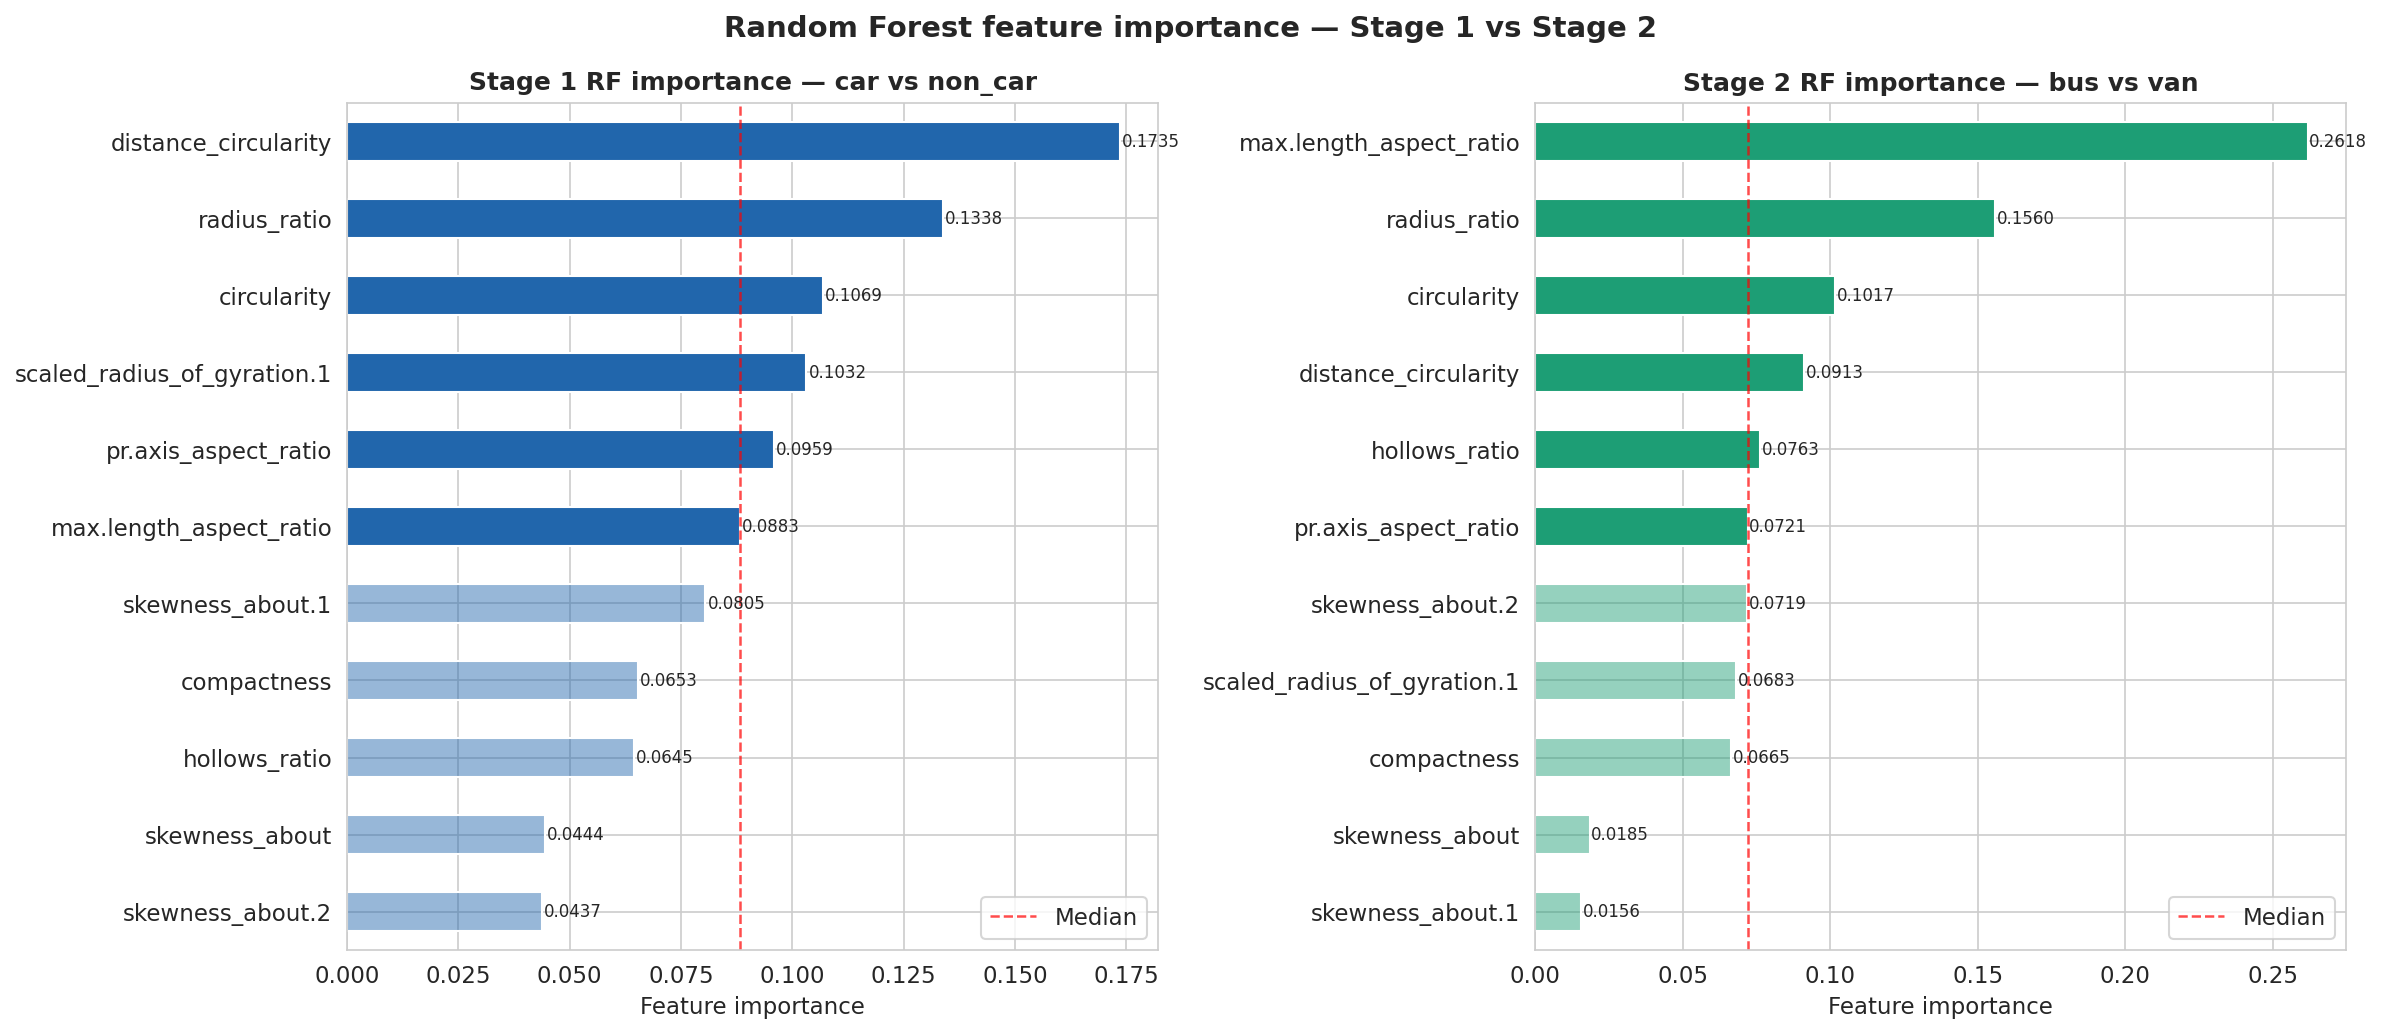

In [39]:
rf1 = res_stage1['Random Forest']['model']
rf2 = res_stage2['Random Forest']['model']
fi1 = pd.Series(rf1.feature_importances_, index=features).sort_values()
fi2 = pd.Series(rf2.feature_importances_, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, fi, title, col in [
    (axes[0], fi1, 'Stage 1 RF importance — car vs non_car', '#2166AC'),
    (axes[1], fi2, 'Stage 2 RF importance — bus vs van',     '#1D9E75'),
]:
    bc = [col if v >= fi.median() else col + '77' for v in fi.values]
    fi.plot(kind='barh', ax=ax, color=bc, edgecolor='white')
    ax.axvline(fi.median(), color='red', linestyle='--',
               lw=1.2, alpha=0.7, label='Median')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Feature importance'); ax.legend()
    for i, v in enumerate(fi.values):
        ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)
plt.suptitle('Random Forest feature importance — Stage 1 vs Stage 2',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
#print("Saved: fig17")

## Fig 9: Confusion matrices — best models (val + test)

In [40]:
def cm_pair_fig(res, best, y_tr, y_va, y_te, cls, title, cmap, fname):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, y_true, y_pred_key, split_label in [
        (axes[0], y_tr, 'train', 'Training set'),
        (axes[1], y_va, 'val',  'Validation set'),
        (axes[2], y_te, 'test', 'Test set'),
    ]:
        cm = confusion_matrix(y_true, res[best][y_pred_key]['y_pred'],
                              labels=cls)

        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                    xticklabels=cls, yticklabels=cls,
                    linewidths=0.5, cbar=False, annot_kws={'size': 14})

        f1 = res[best][y_pred_key]['macro_f1']
        ax.set_title(f'{split_label}\n(Macro F1 = {f1:.3f})',
                     fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

    plt.suptitle(f'{title} — {best}', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

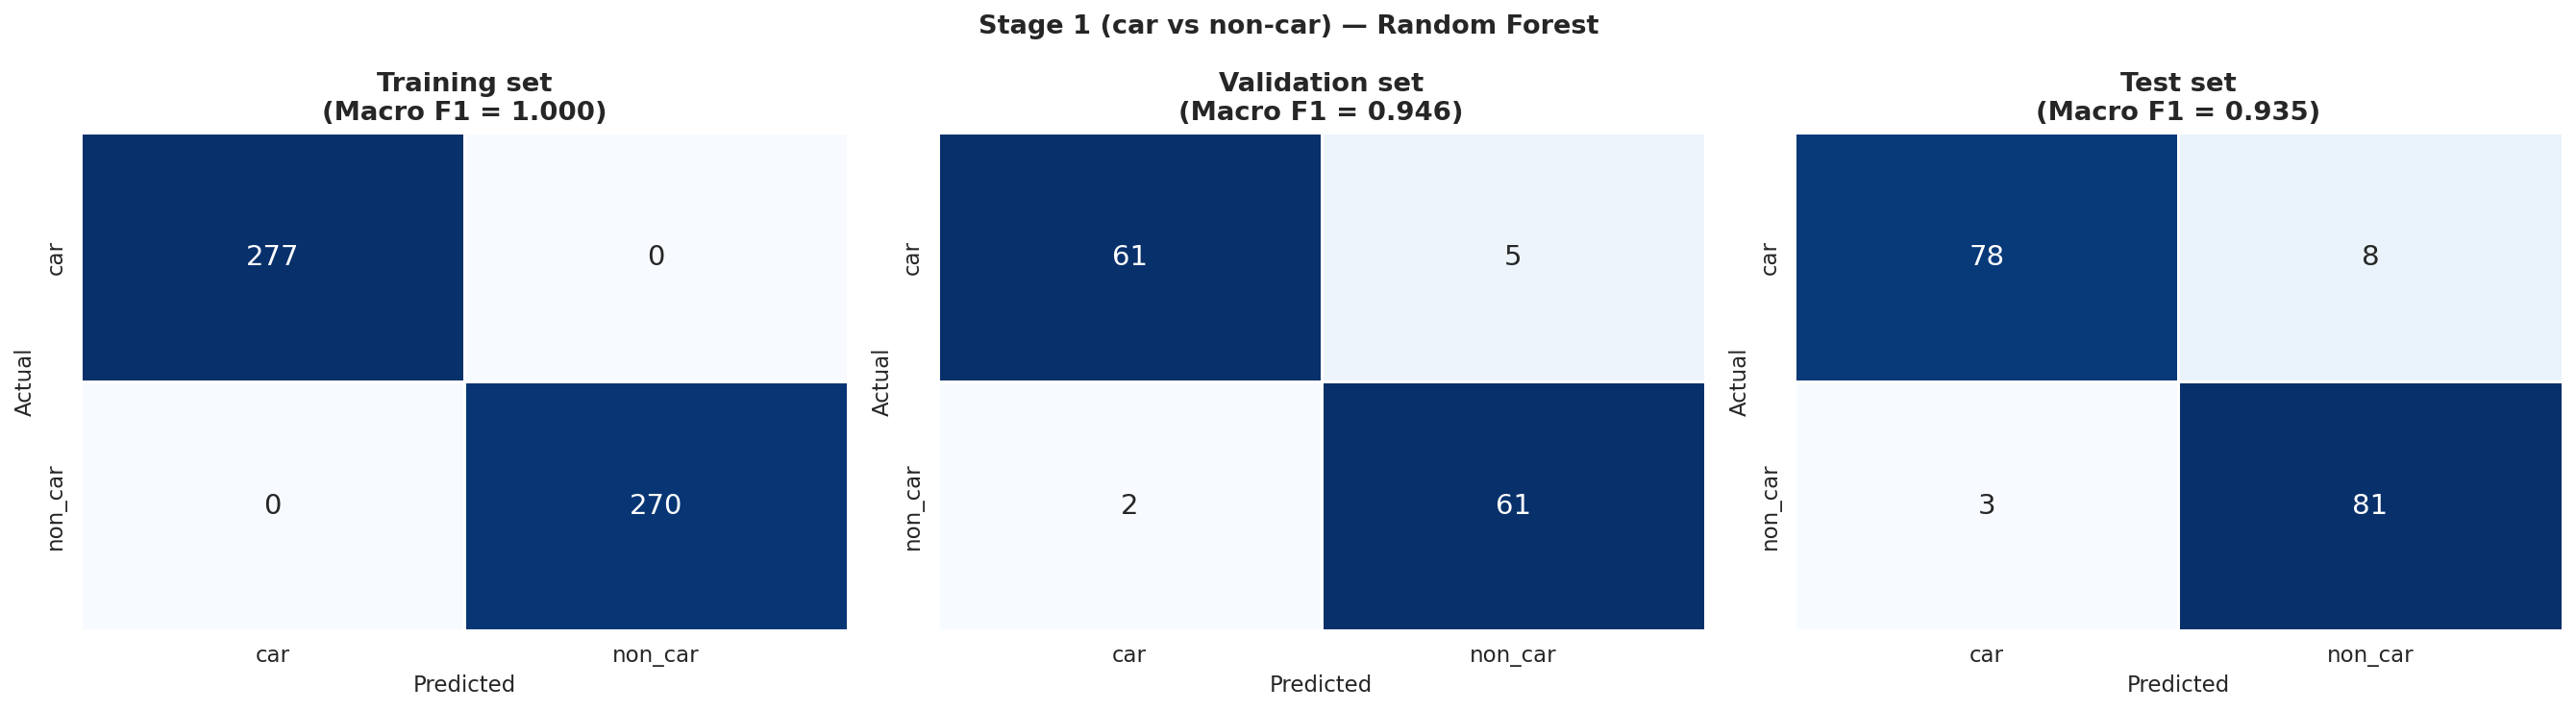

Saved: fig9.1


<Figure size 960x720 with 0 Axes>

In [66]:
cm_pair_fig(res_stage1, best_stage1, y_train_stage1, y_val_stage1, y_test_stage1,
            ['car', 'non_car'],
            'Stage 1 (car vs non-car)', 'Blues',
            'fig4.1_stage1_confusion_val_test.png')
plt.savefig('fig9.1_stage1_confusion_val_test.png', dpi=150, bbox_inches='tight')
print("Saved: fig9.1")

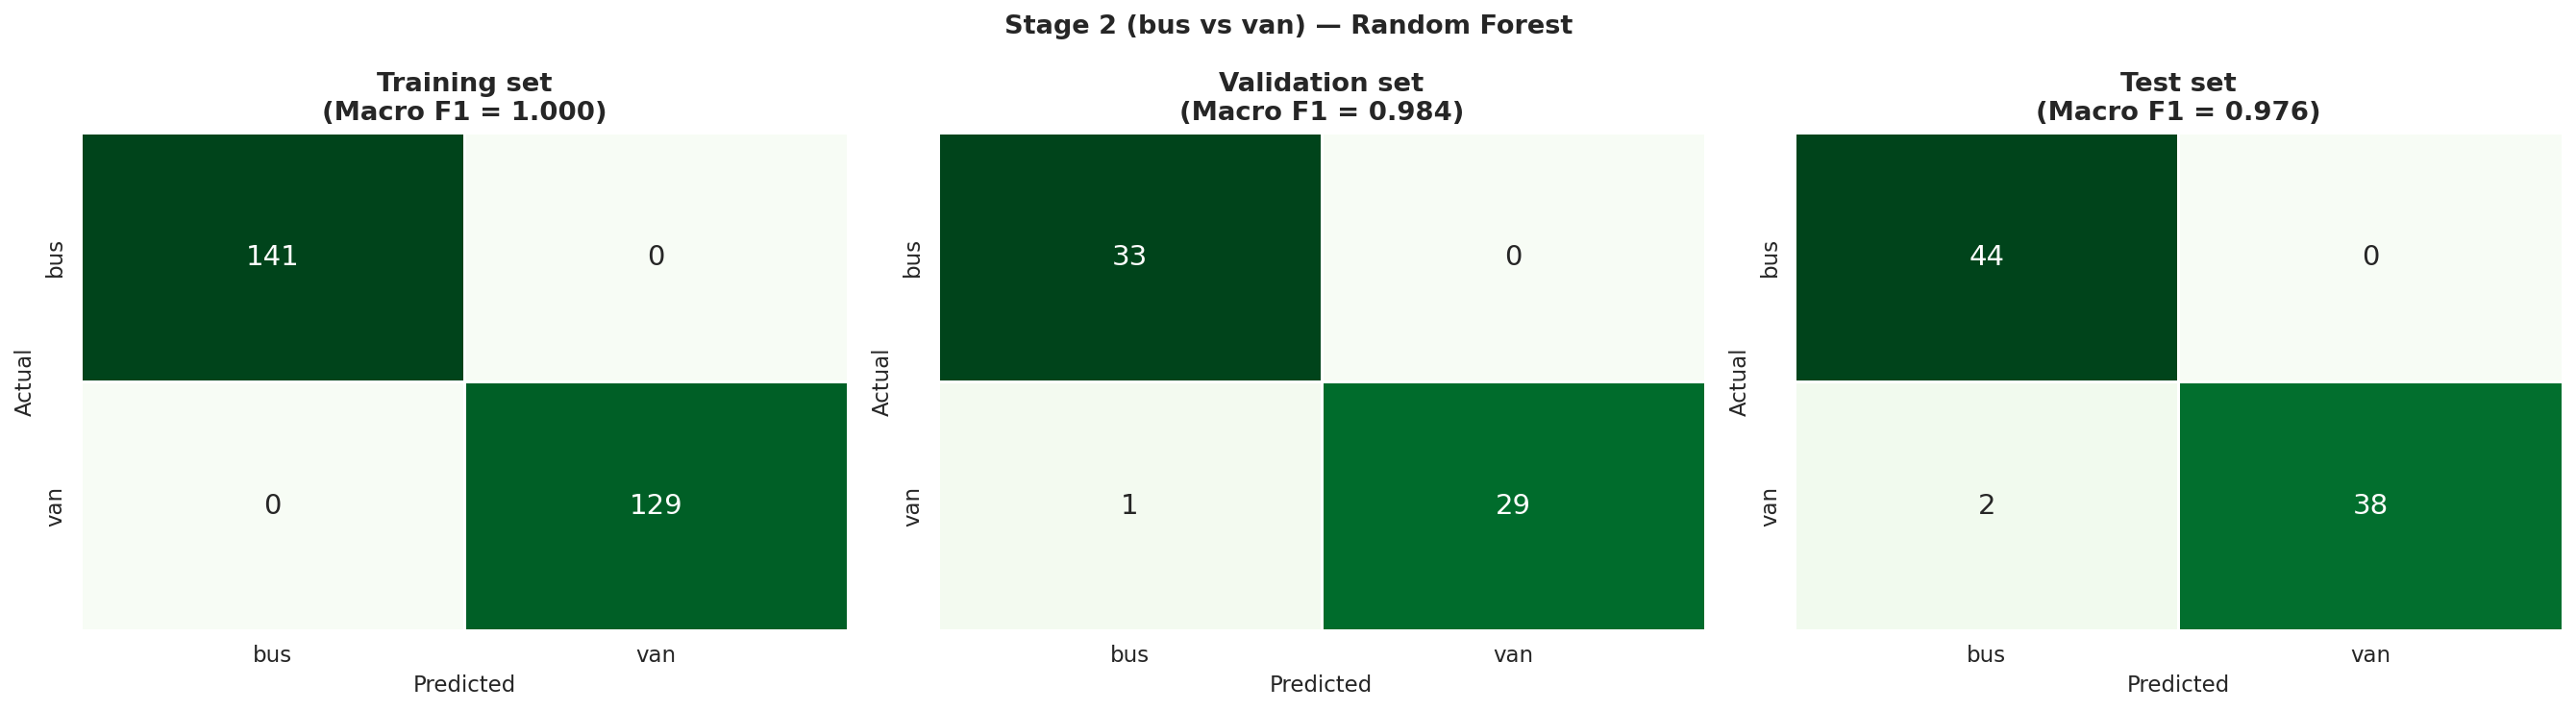

Saved: fig9.2


<Figure size 960x720 with 0 Axes>

In [67]:
cm_pair_fig(res_stage2, best_stage2, y_tr2, y_va2, y_te2,
            ['bus', 'van'],
            'Stage 2 (bus vs van)', 'Greens',
            'fig4.2_stage2_confusion_val_test.png')
plt.savefig('fig9.2_stage2_confusion_val_test.png', dpi=150, bbox_inches='tight')
print("Saved: fig9.2")

# End-to-end evaluation of F1-score

In [43]:
# Calculate end-to-end F1 score
# Get predictions from the best Stage 1 model on the full test set
best_stage1_model = res_stage1[best_stage1]['model']
y_pred_s1_full_test = best_stage1_model.predict(X_te1)

# Identify samples predicted as 'non_car' by Stage 1
non_car_predicted_mask = (y_pred_s1_full_test == 'non_car')

# Get the subset of test data that Stage 1 predicted as 'non_car'
X_test_for_stage2_prediction = X_te1[non_car_predicted_mask]

# Get predictions from the best Stage 2 model on this subset
best_stage2_model = res_stage2[best_stage2]['model']
y_pred_s2_on_filtered_test = best_stage2_model.predict(X_test_for_stage2_prediction)

# Initialize array for final end-to-end predictions
y_pred_e2e = np.empty_like(y_test, dtype=object)

# Assign 'car' predictions
y_pred_e2e[y_pred_s1_full_test == 'car'] = 'car'

# Assign Stage 2 predictions to the 'non_car' predicted samples
y_pred_e2e[non_car_predicted_mask] = y_pred_s2_on_filtered_test

# Calculate end-to-end Macro F1 score
e2e_f1 = f1_score(y_test, y_pred_e2e, average='macro')


# Final summary table

In [44]:
print("\n" + "-" * 65)
print("FINAL SUMMARY")
print("-" * 65)
print(f"Data split       : {n_tr} train  |  {n_va} validation  |  {n_te} test")
print(f"\nStage 1 (car vs non_car) — selected by Validation Macro F1:")
for m in sorted(res_stage1, key=lambda x: res_stage1[x]['val']['macro_f1'], reverse=True):
    marker = ' ★' if m == best_stage1 else '  '
    print(f"  {marker}{m:22s}  Train={res_stage1[m]['train']['macro_f1']:.3f}  "
          f"Val={res_stage1[m]['val']['macro_f1']:.3f}  "
          f"Test={res_stage1[m]['test']['macro_f1']:.3f}")

print(f"\nStage 2 (bus vs van) — selected by Validation Macro F1:")
for m in sorted(res_stage2, key=lambda x: res_stage2[x]['val']['macro_f1'], reverse=True):
    marker = ' ★' if m == best_stage2 else '  '
    print(f"  {marker}{m:22s}  Train={res_stage2[m]['train']['macro_f1']:.3f}  "
          f"Val={res_stage2[m]['val']['macro_f1']:.3f}  "
          f"Test={res_stage2[m]['test']['macro_f1']:.3f}")

print(f"\nEnd-to-end Macro F1 (test set) : {e2e_f1:.4f}")
print(f"Best Stage 1 model             : {best_stage1}")
print(f"Best Stage 2 model             : {best_stage2}")
print(f"\nFigures saved : fig10 – fig20  (20 PNG files)")
print(f"Model saved   : two_stage_model.pkl")
print("-" * 65)


-----------------------------------------------------------------
FINAL SUMMARY
-----------------------------------------------------------------
Data split       : 547 train  |  129 validation  |  170 test

Stage 1 (car vs non_car) — selected by Validation Macro F1:
   ★Random Forest           Train=1.000  Val=0.946  Test=0.935
    SVM                     Train=0.991  Val=0.946  Test=0.965
    Logistic Reg.           Train=0.929  Val=0.922  Test=0.912
    Gradient Boosting       Train=1.000  Val=0.922  Test=0.929
    KNN                     Train=0.940  Val=0.899  Test=0.912
    Decision Tree           Train=0.963  Val=0.860  Test=0.824

Stage 2 (bus vs van) — selected by Validation Macro F1:
   ★Random Forest           Train=1.000  Val=0.984  Test=0.976
    Gradient Boosting       Train=1.000  Val=0.968  Test=0.964
    SVM                     Train=0.985  Val=0.968  Test=0.964
    KNN                     Train=0.940  Val=0.920  Test=0.964
    Logistic Reg.           Train=0.918  Val

# **UNSUPERVISED MACHINE LEARNING**

## Vehicle Clustering around a `CENTROID`


## Import Extra Libraries

In [45]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

## Preparing data for clustering

In [46]:
data_unsupervised = pd.concat([
    pd.DataFrame(X_train, columns=features),
    pd.DataFrame(X_val, columns=features),
    pd.DataFrame(X_test, columns=features)
], axis=0).reset_index(drop=True)

In [47]:
data_unsupervised.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,86.0,45.0,70.0,122.0,56.0,7.0,84.0,9.0,5.0,180.0,183.0
1,90.0,47.0,85.0,161.0,64.0,10.0,73.0,9.0,0.0,185.0,195.0
2,107.0,56.0,105.0,202.0,61.0,11.0,72.0,15.0,1.0,189.0,196.0
3,83.0,46.0,71.0,156.0,70.0,6.0,80.0,3.0,11.0,181.0,186.0
4,88.0,34.0,69.0,152.0,57.0,5.0,62.0,9.0,29.0,204.0,210.0


In [48]:
data_unsupervised.shape

(846, 11)

In [49]:
data_unsupervised.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    float64
 1   circularity                  846 non-null    float64
 2   distance_circularity         846 non-null    float64
 3   radius_ratio                 846 non-null    float64
 4   pr.axis_aspect_ratio         846 non-null    float64
 5   max.length_aspect_ratio      846 non-null    float64
 6   scaled_radius_of_gyration.1  846 non-null    float64
 7   skewness_about               846 non-null    float64
 8   skewness_about.1             846 non-null    float64
 9   skewness_about.2             846 non-null    float64
 10  hollows_ratio                846 non-null    float64
dtypes: float64(11)
memory usage: 72.8 KB


## Scaling `Standard Scaler`


In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_unsupervised)

In [51]:
#X_scaled

## Principal Component Analysis (PCA)

In [52]:
pca = PCA(n_components=3, random_state=8)
principal_comp = pca.fit_transform(X_scaled)

In [53]:
pca_df = pd.DataFrame(data = principal_comp, columns = ['principal_component_1', 'principal_component_2', 'principal_component_3'])
pca_df.head()

,principal_component_1,principal_component_2,principal_component_3
0,-2.964061,1.496934,-0.736399
1,-0.322735,0.679781,0.126413
2,2.383944,1.341846,-1.487015
3,-1.931349,1.463663,0.668341
4,0.297280,-4.071792,0.679486


In [54]:
pca_df

,principal_component_1,principal_component_2,principal_component_3
0,-2.964061,1.496934,-0.736399
1,-0.322735,0.679781,0.126413
2,2.383944,1.341846,-1.487015
3,-1.931349,1.463663,0.668341
4,0.297280,-4.071792,0.679486
...,...,...,...
841,-3.489603,1.682291,-1.118197
842,-3.102445,0.777890,-1.473980
843,-4.128405,0.588677,-0.082867
844,-1.344321,0.937049,-0.303553


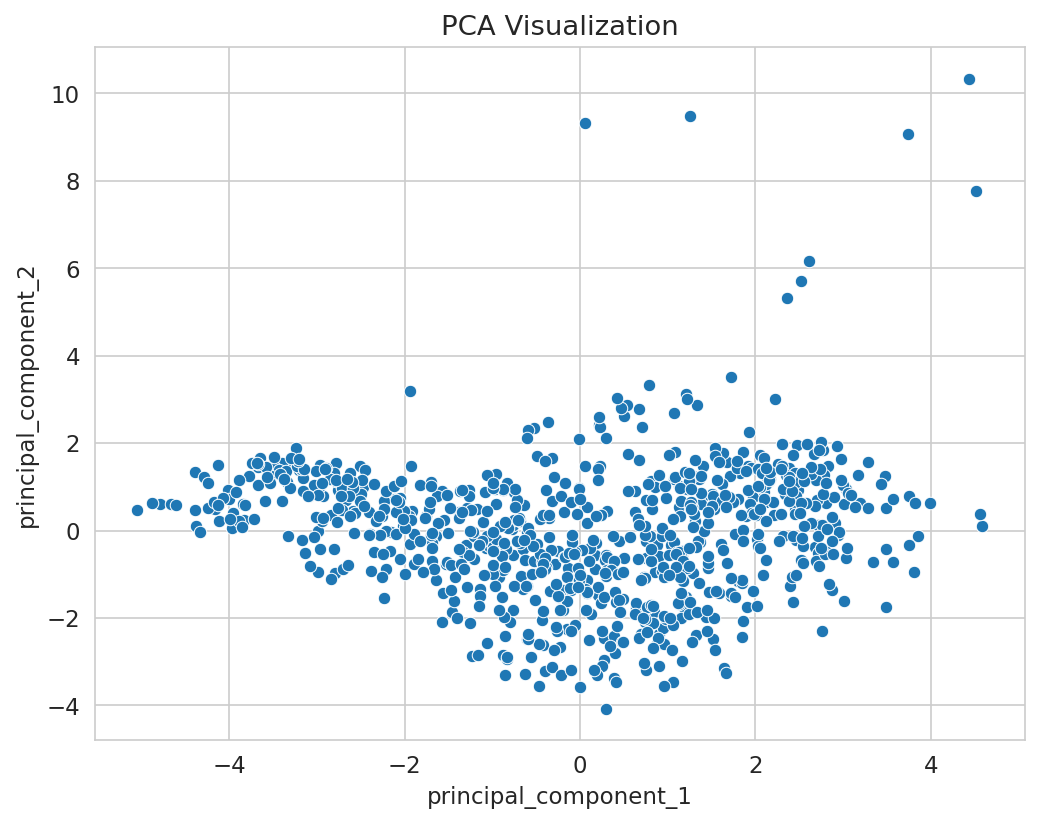

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_df.principal_component_1, y=pca_df.principal_component_2)
plt.title('PCA Visualization')
plt.savefig('fig11_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## Kmeans Clustering

choosing the optimal number of cluster (k) using the elbow method

In [56]:
inertia = []
k_range = range(1, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

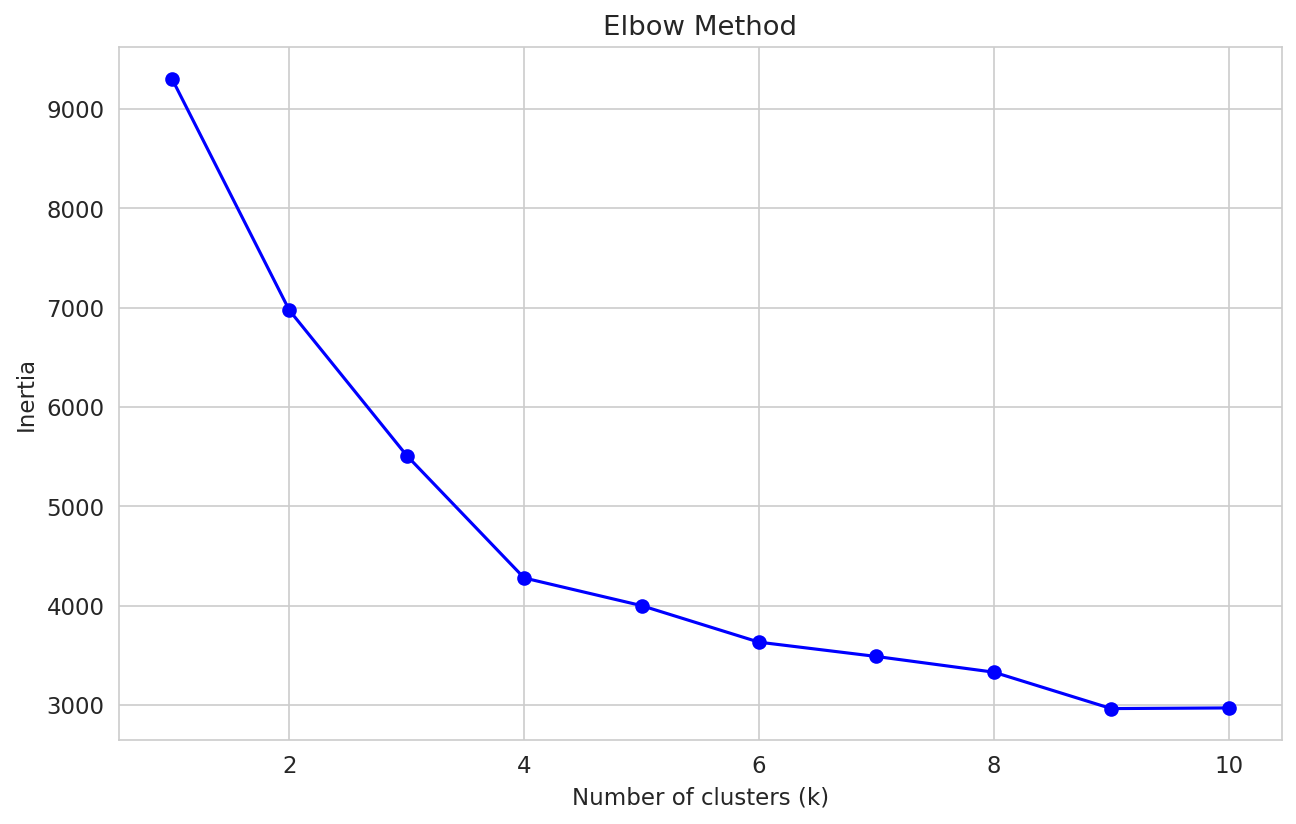

In [57]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.savefig('fig12_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
optimal_k = 6

In [59]:
kmeans = KMeans(n_clusters=optimal_k, random_state=8)
cluster_labels = kmeans.fit_predict(data_unsupervised)

In [60]:
#cluster_labels

Joining the cluster labels to the dataframe

In [61]:
data_unsupervised = data_unsupervised.copy()
data_unsupervised.loc[:, 'cluster_labels'] = cluster_labels

In [62]:
data_unsupervised.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,cluster_labels
0,86.0,45.0,70.0,122.0,56.0,7.0,84.0,9.0,5.0,180.0,183.0,4
1,90.0,47.0,85.0,161.0,64.0,10.0,73.0,9.0,0.0,185.0,195.0,3
2,107.0,56.0,105.0,202.0,61.0,11.0,72.0,15.0,1.0,189.0,196.0,1
3,83.0,46.0,71.0,156.0,70.0,6.0,80.0,3.0,11.0,181.0,186.0,0
4,88.0,34.0,69.0,152.0,57.0,5.0,62.0,9.0,29.0,204.0,210.0,0


## Relationship between Features and Cluster Labels

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
cluster_labels,,,,,,,,,,,
0,87.886010,41.865285,72.886010,144.326425,59.430052,7.891192,71.595855,5.689119,10.181347,188.352332,195.067358
1,101.739645,50.059172,97.497041,189.781065,60.076923,8.958580,71.775148,7.420118,13.940828,189.822485,196.650888
2,102.781955,52.105263,102.037594,215.639098,66.586466,9.969925,70.345865,6.533835,16.157895,189.699248,198.857143
3,92.392157,41.838235,78.411765,171.759804,64.333333,7.901961,68.205882,6.112745,12.602941,193.632353,200.514706
4,85.446043,39.956835,62.762590,122.892086,55.007194,6.323741,80.539568,6.287770,11.035971,181.194245,185.115108
5,87.625000,45.250000,77.750000,268.125000,116.250000,49.250000,109.500000,5.000000,10.625000,184.625000,192.375000


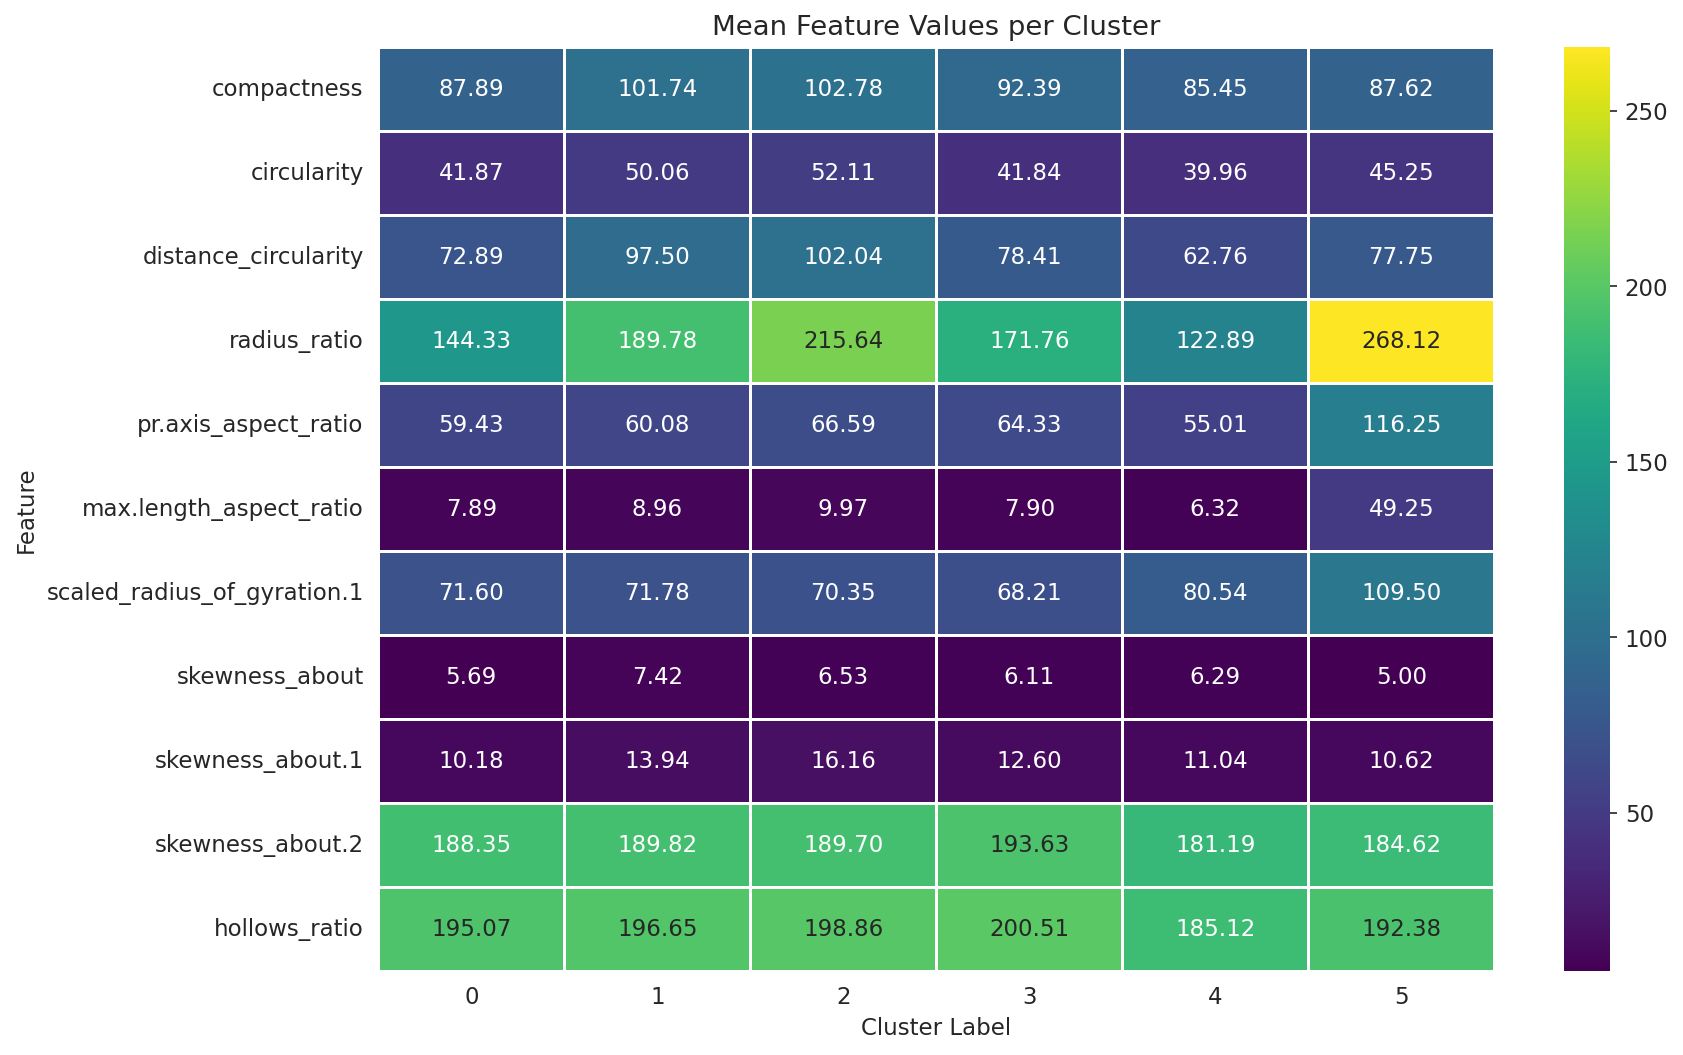

In [63]:
# Calculate the mean of each feature for each cluster
cluster_feature_means = data_unsupervised.groupby('cluster_labels')[features].mean()

# Display the means
display(cluster_feature_means)

# Visualize the relationship using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_feature_means.T, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Mean Feature Values per Cluster')
plt.xlabel('Cluster Label')
plt.ylabel('Feature')
plt.savefig('fig13_cluster_feature_means.png', dpi=150, bbox_inches='tight')
plt.show()

## Box Plots: Feature Distribution per Cluster

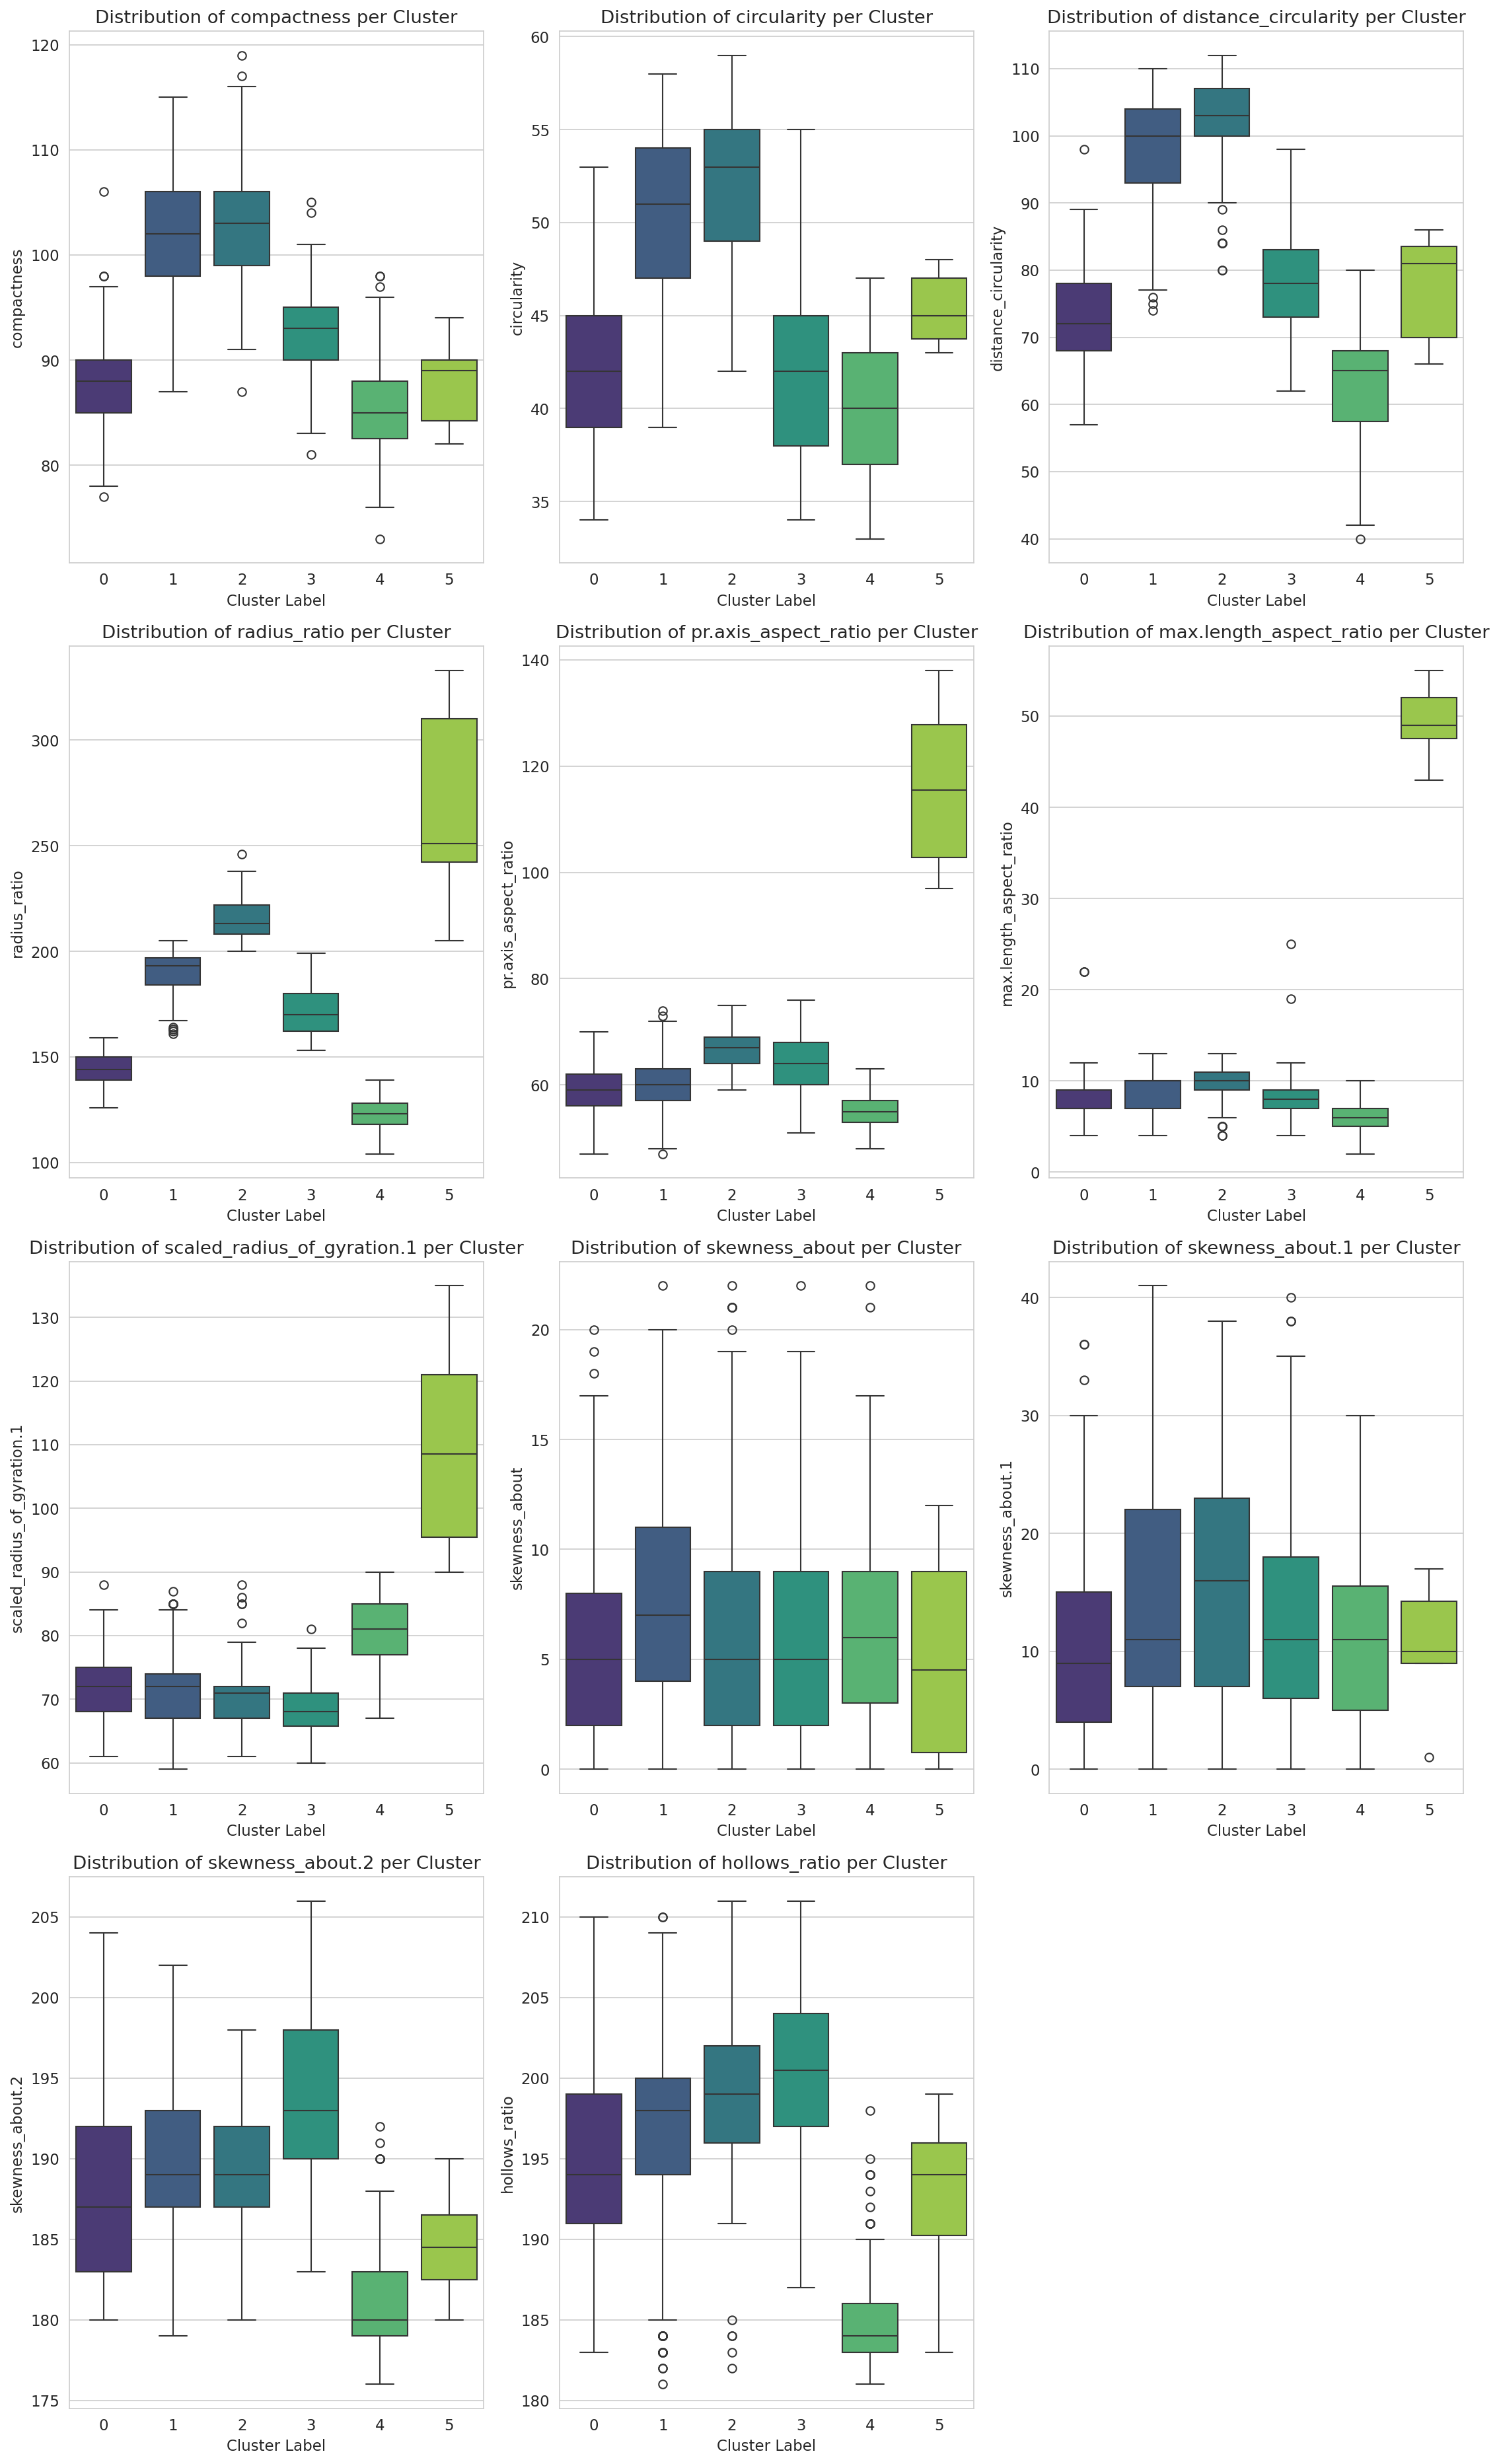

In [64]:
plt.figure(figsize=(15, 25))
for i, feature in enumerate(features):
    plt.subplot(len(features) // 3 + 1, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='cluster_labels', y=feature, data=data_unsupervised, palette='viridis')
    plt.title(f'Distribution of {feature} per Cluster')
    plt.xlabel('Cluster Label')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

In [65]:
data_unsupervised.cluster_labels.value_counts()

,count
cluster_labels,
3,204
0,193
1,169
4,139
2,133
5,8
